# H1 Analysis: Reasoning-Trace Efficiency and Trajectory Study

This notebook reconstructs the full H1 analysis from a **single raw results file** (`h1_raw_results.csv`). Everything else (difficulty levels, group eligibility, metrics, figures, CSV outputs) is derived from it. It is organized into four top-level analyses:

1. **Over Samples Analysis**: sample/path-level study of *how* models reason within a fixed `(question_id, compute_level)` group, split into three sub-studies by group outcome (all-correct / mixed / all-wrong).
2. **Over Benchmarks Analysis**: accuracy vs. compute level per benchmark, with a Kneedle-based "optimal" compute level per benchmark.
3. **Over Compute Level Analysis**: a benchmark-size-robust, normalized aggregate accuracy-vs-compute curve across all benchmarks.
4. **Over Difficulty Level Analysis**: the same methodology as Analyses 2 and 3, with *difficulty level* (derived from the data) as the grouping dimension instead of benchmark.

All text-analysis machinery (segmentation, answer extraction, SBERT similarity/novelty, segment labeling, answer tracking) is implemented once in Section 0 and reused identically across Studies 1-3.

**Requirements:** `pandas numpy scipy statsmodels scikit-learn matplotlib kneed sentence-transformers` (the SBERT model `all-MiniLM-L6-v2` is downloaded on first use).

**Required columns in `h1_raw_results.csv`:** `question_id`, `compute_level`, `is_correct`, `thinking_text`, `thinking_tokens`, `benchmark`. Optional: `raw_model_output`, `output_tokens`, `was_truncated`/`truncated`, `gold`.

Findings throughout are **descriptive / associational**, not causal.

## 0. Setup and Configuration

Imports, paths, and one `CFG` dictionary holding every threshold and weight used below. All outputs (CSVs, figures) are written next to the input file.

In [ ]:
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.metrics.pairwise import cosine_similarity
from kneed import KneeLocator
from IPython.display import display
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

BASE_DIR = Path("../results/h1_testing")
INPUT_CSV = BASE_DIR / "h1_raw_results.csv"   # the ONLY raw input
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BENCHMARK_COL = "benchmark"

CFG = dict(
    seed=0,

    # similarity / novelty thresholds
    sim_repeat={"sbert": 0.85},
    sim_dup_verif=0.90,
    sim_revisit=0.50,

    w_sem_novelty=0.5,
    tau_new=0.35,
    tau_new_high=0.60,
    min_post_tokens=30,
    ngram_window=128,

    include_output_text=True,
    mc_letters="ABCDEFGHIJ",

    embedder="sbert:all-MiniLM-L6-v2",
    n_boot=1000,
    n_viz_groups=4,
    viz_x_mode="tokens",

    # efficiency score (Study 1)
    score=dict(
        weights=dict(
            c_info=0.25,
            c_nonred=0.20,
            c_div=0.10,
            c_stab=0.10,
            c_conf=0.10,
            c_verif=0.10,
            c_necess=0.15,
        ),
        agg="arith",
        geo_eps=0.02,
        rate_floor_tokens=1000,
        caps=dict(
            info=0.60,
            red=0.60,
            div_lo=0.50,
            div_hi=0.95,
            flips_per_1k=3.0,
            doubt_per_1k=10.0,
        ),
        verif_missing=0.5,
    ),

    # pass/fail criteria for the score validation suite
    sanity=dict(
        min_rank_corr_weights_p05=0.85,
        min_rank_corr_loo=0.75,
        max_single_component_rank_corr=0.90,
        max_abs_length_rho=0.50,
        max_length_r2=0.50,
    ),

    # Analysis 4: difficulty bands on per-question pass rate (see Section 4.1)
    difficulty=dict(
        edges=[0.0, 0.25, 0.50, 0.75, 1.0000001],
        labels=["D1_hard", "D2_medium_hard", "D3_medium_easy", "D4_easy"],
    ),
)

GK = ["question_id", "compute_level"]   # group key
MIN_GROUP_N = 3            # Study 1 minimum paths per group
MIN_GROUP_N_S23 = 2        # Studies 2/3 minimum paths per group
MIN_LEN_RATIO = 1.5        # min max/min token ratio for extra-token attribution
SEG_MIN_CHARS = 15
SEG_MAX_SEGMENTS = 2000
SIM_REPEAT = CFG["sim_repeat"]["sbert"]

RNG = np.random.default_rng(CFG["seed"])
np.random.seed(CFG["seed"])

### 0.1 Loading and normalizing the raw dataset

The raw CSV is loaded exactly once. `is_correct` is normalized explicitly from its true-like / false-like representations (never via `.astype(bool)` on strings, which would silently treat `"FALSE"` as truthy) and stored as float (`1.0 / 0.0 / NaN`) so group means and sums work. `question_id` and `compute_level` are coerced to strings so they group and merge consistently. `thinking_tokens` falls back to a `len(text)/4` estimate when missing or non-positive.

If a visible `raw_model_output` column exists and `CFG["include_output_text"]` is on, it is appended to the analyzed text (short bare outputs are wrapped as `"Final answer: <output>."` so the answer-extraction regexes can find them). `thinking_tokens` is kept separate from `full_tokens` (thinking + output) because Study 1's length analysis is defined over `thinking_tokens`.

In [38]:
raw_df = pd.read_csv(INPUT_CSV)
raw_df["row_id"] = raw_df.index
print(f"Loaded {len(raw_df):,} rows | "
      f"{raw_df['question_id'].nunique():,} questions | "
      f"{raw_df['compute_level'].nunique()} compute levels")
if BENCHMARK_COL not in raw_df.columns:
    print(f"WARNING: benchmark column '{BENCHMARK_COL}' not found in raw data; "
          f"set BENCHMARK_COL to the actual column name before Section 2.")
raw_df.head(3)

Loaded 3,150 rows | 90 questions | 7 compute levels


,question_id,benchmark,difficulty_tier,task_type,compute_level,sample_index,raw_model_output,thinking_text,gold,is_correct,tokens_used,thinking_tokens,output_tokens,hit_response_marker,latency_s,was_truncated,hit_marker_empty_output,row_id
0,GSM8K_0,GSM8K,easy,math,0,2,Janet's ducks lay **16 eggs** per day. \nShe ...,NaN,18,True,96,0,93,True,2.883648,False,False,0
1,GSM8K_0,GSM8K,easy,math,0,1,Janet's ducks lay 16 eggs per day. She uses 3 ...,NaN,18,True,113,0,110,True,3.440018,False,False,1
2,GSM8K_0,GSM8K,easy,math,0,0,Janet's ducks lay 16 eggs each day. From these...,NaN,18,True,138,0,135,True,4.148850,False,False,2


In [39]:
for col in ["hit_response_marker",
            "was_truncated",
            "hit_marker_empty_output"]:
    print(f"value count of {col} is {raw_df[col].value_counts()}\n{40*"-"}")

raw_df = raw_df[~raw_df["hit_marker_empty_output"]].copy()

value count of hit_response_marker is hit_response_marker
True    3150
Name: count, dtype: int64
----------------------------------------
value count of was_truncated is was_truncated
False    3150
Name: count, dtype: int64
----------------------------------------
value count of hit_marker_empty_output is hit_marker_empty_output
False    3139
True       11
Name: count, dtype: int64
----------------------------------------


## 1 Shared text-analysis pipeline

The following block implements the shared text-analysis machinery used to analyze individual reasoning paths.

1. **Answer normalization.** Raw answers and reference answers are converted to a common representation before comparison. Numeric values are converted to a canonical significant-figure representation, fractions are evaluated, multiple-choice letters are normalized to uppercase, and surrounding whitespace/certain punctuation are removed. Reference answers can additionally be extracted from `\boxed{...}` expressions or serialized grading metadata.

2. **Answer candidate extraction.** Each segment is scanned for numeric and multiple-choice candidate values. Numeric fractions, integers, decimals, and option letters are detected with regular expressions. Candidate mentions preceded by a local negation pattern (e.g. `the answer is not 5`) are excluded.

3. **Explicit answer assertions.** Candidate mentions are distinguished from committed answer assertions. A segment is treated as asserting an answer when it contains an answer cue such as `the answer is`, `final answer`, `therefore the answer is`, `we get`, or `equals`, followed by a detectable numeric or multiple-choice value. `\boxed{...}` answers are also treated as explicit assertions. Segments containing hedge cues such as `maybe`, `I think`, or `probably` are not treated as committed assertions. This prevents tentative mentions from being counted as genuine answer changes.

4. **Segmentation.** Each reasoning trace is divided into analysis segments using newlines and sentence-like punctuation. Very short fragments are merged with neighboring segments, and excessively fragmented traces are coarsened by repeatedly merging adjacent pairs. The resulting segments are the basic units for all subsequent reasoning-path analysis.

5. **Segment-level raw features.** Each segment receives heuristic linguistic features indicating whether it contains candidate answers, an explicit answer, hedge language, doubt/self-correction cues, rejection cues, or verification cues. Segment character length is also retained.

6. **Reference answer resolution.** When a gold answer is available, the normalized gold answer is used as the reference. Otherwise, the most frequent normalized final answer within the `question_id × compute_level` group is used when it covers at least 50% of the paths. If no sufficient consensus exists, the reference is left unresolved and the path's own final answer can be handled upstream.

7. **Semantic similarity and novelty.** Segments are embedded using `sentence-transformers/all-MiniLM-L6-v2`. For each segment, `max_sim_prev` is the maximum cosine similarity to any earlier segment in the same path. Semantic novelty is defined as `1 − max_sim_prev`. This is combined with content-word novelty to obtain the final `novelty` score, allowing the analysis to distinguish semantically repetitive reasoning from reasoning that introduces new content.

8. **Answer-state tracking.** Across the path, the pipeline tracks the first explicit answer assertion, changes between asserted answer values (`answer_flips`), repeated assertions of the same value (`n_restate`), doubt/rejection events (`n_doubt`), and verification events that revisit semantically similar earlier content (`n_revisit`).

9. **Segment labels.** Each segment receives one mutually exclusive label using the following priority order: `first_answer` › `wrong_candidate` › `verification` › `doubt` › `restate` › `repetition` › `new_reasoning` / `before_answer`. `first_answer` marks the first committed answer assertion; `wrong_candidate` marks an explicit answer that differs from the resolved reference; `verification` marks verification cues; `doubt` marks hesitation or self-correction; `restate` marks subsequent assertions of an already-held answer; `repetition` marks highly similar content; and the remaining segments are classified according to their novelty and whether the first answer has already occurred.

**Limitations that matter for interpretation.** The answer and behavioral cues are English-language heuristic regular expressions rather than a semantic classifier. Candidate extraction is most reliable for short numeric and multiple-choice answers. Semantic novelty depends on the SBERT embedding model and the selected similarity/novelty thresholds. The segmentation procedure is character-based and therefore does not provide exact linguistic units. Path-level counters are repeated across segment rows for convenience and should be interpreted as path-level, not segment-level, quantities. The resulting labels and metrics should therefore be audited against representative reasoning paths before being used for aggregate conclusions.


In [40]:
# Answer normalization

_EDGE_PUNCT = "$.,;:* \t\n"   # stripped from the ends only, never from the middle (keeps decimals)
_STOPWORDS = {
    "a", "an", "the", "is", "are", "was", "were", "be", "been", "being",
    "to", "of", "in", "on", "at", "for", "and", "or", "but", "if", "this",
    "that", "these", "those", "it", "as", "so", "we", "i", "you", "he",
    "she", "they", "them", "with", "by", "from", "will", "would", "can",
    "could", "should", "not", "no", "do", "does", "did", "have", "has",
    "had", "then", "than", "let", "us", "let's", "s", "our", "my", "your",
}

def _sigfig(x: float, n: int = 6) -> str:
    """Round to n significant figures and render without trailing zeros."""
    if x == 0:
        return "0"
    d = math.ceil(math.log10(abs(x)))
    power = n - d
    factor = 10 ** power
    val = round(x * factor) / factor
    if val == int(val):
        return str(int(val))
    return f"{val:.{max(power, 0)}f}".rstrip("0").rstrip(".")

_FRACTION_RE = re.compile(r"^-?\d+\s*/\s*\d+$")

def normalize_answer(raw, mc_letters=CFG["mc_letters"]):
    """Normalize an extracted or reference answer string."""
    if raw is None:
        return None
    s = str(raw).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return None
    s = s.strip(_EDGE_PUNCT)                       # leading/trailing $ . , ; : *
    if s.endswith("%"):
        s = s[:-1].strip(_EDGE_PUNCT)
    if re.fullmatch(r"-?\d{1,3}(,\d{3})+(\.\d+)?", s):   # thousands separators only
        s = s.replace(",", "")
    if _FRACTION_RE.match(s):
        try:
            num, den = s.split("/")
            return _sigfig(float(num) / float(den))
        except Exception:
            pass
    try:
        return _sigfig(float(s))
    except ValueError:
        pass
    if len(s) == 1 and s.upper() in mc_letters:
        return s.upper()
    return re.sub(r"\s+", " ", s.lower()).strip()

_BOXED_RE = re.compile(r"\\boxed\{((?:[^{}]|\{[^{}]*\})*)\}")

def resolve_reference_string(raw_gold):
    """Extract/normalize a reference (gold) answer, handling boxed LaTeX and
    filtering out serialized grading metadata rather than treating it as a
    literal answer."""
    if pd.isna(raw_gold):
        return None
    s = str(raw_gold).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return None
    # dict/list-like serialized metadata is not a literal answer
    if (s.startswith("{") and s.endswith("}")) or (s.startswith("[") and s.endswith("]")):
        try:
            parsed = json.loads(s)
            if isinstance(parsed, dict):
                for key in ("answer", "value", "gold", "final_answer"):
                    if key in parsed:
                        return normalize_answer(parsed[key])
                return None
        except Exception:
            return None
    m = _BOXED_RE.findall(s)
    if m:
        s = m[-1]
    return normalize_answer(s)

In [41]:
#Regex-based answer extraction
_NUM = r"-?\d{1,3}(?:,\d{3})*(?:\.\d+)?|-?\d+\.\d+|-?\d+"
_SIMPLE_FRAC = r"-?\d+\s*/\s*\d+"
_NUMERIC_CANDIDATE_RE = re.compile(rf"({_SIMPLE_FRAC}|{_NUM})")
_MC_CANDIDATE_RE = re.compile(rf"\b([A-{CFG['mc_letters'][-1]}])\b")

_ANSWER_CUE_RE = re.compile(
    r"(?:final answer|the answer is|answer:|so the answer is|therefore,? the answer is|"
    r"we get|equals|is equal to|correct answer is|i choose|the answer would be)\s*[:=]?\s*",
    re.IGNORECASE,
)
_BOXED_INLINE_RE = re.compile(r"\\boxed\{((?:[^{}]|\{[^{}]*\})*)\}")
_HEDGE_RE = re.compile(
    r"\b(maybe|perhaps|i think|possibly|might be|could be|not sure|"
    r"i believe|probably|seems like|it seems)\b", re.IGNORECASE,
)
_DOUBT_RE = re.compile(
    r"\b(wait|hmm|hold on|let me reconsider|actually,? (?:no|wait)|"
    r"that('?s| is) (?:not right|wrong|incorrect)|i (?:made|think i made) a mistake|"
    r"let me (?:re-?check|reconsider|recompute|redo))\b", re.IGNORECASE,
)
_REJECTION_RE = re.compile(
    r"\b(that'?s wrong|that is incorrect|scratch that|let me (?:start over|try again)|"
    r"no,? that('?s)? not (?:it|right)|i was wrong|correcting myself)\b", re.IGNORECASE,
)
_VERIFICATION_RE = re.compile(
    r"\b(let me verify|to check|checking|let'?s double-?check|verify(?:ing)?|"
    r"confirm(?:ing)?|sanity check|let me confirm|to make sure|plugging back in)\b",
    re.IGNORECASE,
)
_NEGATION_WINDOW_RE = re.compile(
    r"\b(not|isn'?t|is not|n'?t)\s+(?:equal to\s+)?$", re.IGNORECASE,
)

def _negation_context(text: str, match_start: int, window: int = 25) -> bool:
    """True if the candidate value is preceded by a negation within `window`
    chars (e.g. 'the answer is not 5' should not assert 5)."""
    ctx = text[max(0, match_start - window):match_start]
    return bool(_NEGATION_WINDOW_RE.search(ctx))

def extract_candidates(text: str):
    """Return list of (value_str, start_idx, is_mc) numeric/MC candidate
    mentions in a segment, skipping negated mentions."""
    out = []
    for m in _NUMERIC_CANDIDATE_RE.finditer(text):
        if _negation_context(text, m.start()):
            continue
        out.append((m.group(1).replace(",", ""), m.start(), False))
    for m in _MC_CANDIDATE_RE.finditer(text):
        if _negation_context(text, m.start()):
            continue
        out.append((m.group(1), m.start(), True))
    return out

def extract_explicit_answer(text: str):
    """Return the normalized explicit/committed answer in a segment, or
    None. A hedged segment never produces a committed explicit answer."""
    boxed_match = _BOXED_INLINE_RE.search(text)
    if boxed_match:
        val = _BOXED_INLINE_RE.findall(text)[-1]
        if _HEDGE_RE.search(text[:boxed_match.start()]):
            return None
        return normalize_answer(val)
    cue = _ANSWER_CUE_RE.search(text)
    if cue:
        tail = text[cue.end():cue.end() + 40]
        if _HEDGE_RE.search(text[:cue.start()]):
            return None
        cand = _NUMERIC_CANDIDATE_RE.search(tail) or _MC_CANDIDATE_RE.search(tail)
        if cand:
            if _negation_context(tail, cand.start()):
                return None
            return normalize_answer(cand.group(1))
    return None

In [42]:
# Segmentation
_SENT_SPLIT_RE = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9\\$])")

def segment_text(text: str):
    """Split a trace into analysis segments: newline blocks, then
    sentence-split, then merge short fragments (<15 chars) forward/back,
    then coarsen traces with >2000 segments by merging adjacent pairs."""
    if text.strip() == "":
        return ["(no output)"]
    norm = re.sub(r"\r\n?", "\n", text)
    blocks = [b.strip() for b in re.split(r"\n\s*\n|\n", norm) if b.strip() != ""]
    segs = []
    for b in blocks:
        parts = _SENT_SPLIT_RE.split(b)
        segs.extend([p.strip() for p in parts if p.strip() != ""])
    if not segs:
        return ["(no output)"]
    merged = []
    buf = ""
    for s in segs:
        buf = (buf + " " + s).strip() if buf else s
        if len(buf) >= SEG_MIN_CHARS:
            merged.append(buf)
            buf = ""
    if buf:
        if merged:
            merged[-1] = merged[-1] + " " + buf
        else:
            merged.append(buf)
    while len(merged) > SEG_MAX_SEGMENTS:
        coarsened = []
        for i in range(0, len(merged) - 1, 2):
            coarsened.append(merged[i] + " " + merged[i + 1])
        if len(merged) % 2 == 1:
            coarsened.append(merged[-1])
        merged = coarsened
    return merged

In [43]:
# Segment-level raw features
def segment_raw_features(seg_text: str):
    return dict(
        candidates=extract_candidates(seg_text),
        explicit_answer=extract_explicit_answer(seg_text),
        has_hedge=bool(_HEDGE_RE.search(seg_text)),
        has_doubt=bool(_DOUBT_RE.search(seg_text)),
        has_rejection=bool(_REJECTION_RE.search(seg_text)),
        has_verification=bool(_VERIFICATION_RE.search(seg_text)),
        n_chars=len(seg_text),
    )

In [44]:
#Reference-answer resolution
def resolve_group_reference(group_df: pd.DataFrame, gold_col_present: bool):
    """Group mode: prefer normalized gold, else >=50% consensus of the group's
    own final answers, else no reference (own_final)."""
    if gold_col_present:
        golds = group_df["gold"].dropna()
        if len(golds) > 0:
            norm_golds = golds.apply(resolve_reference_string).dropna()
            if len(norm_golds) > 0:
                vals, counts = np.unique(norm_golds, return_counts=True)
                return vals[np.argmax(counts)], "gold"
    finals = group_df["_own_final_norm"].dropna()
    if len(finals) > 0:
        vals, counts = np.unique(finals, return_counts=True)
        top_val, top_count = vals[np.argmax(counts)], counts.max()
        if top_count / len(group_df) >= 0.5:
            return top_val, "consensus"
    return None, "own_final"

In [45]:
#  SBERT embedder
_SBERT_MODEL = None

def get_sbert_model():
    """Lazy-load the SBERT model once."""
    global _SBERT_MODEL
    if _SBERT_MODEL is None:
        from sentence_transformers import SentenceTransformer
        _SBERT_MODEL = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    return _SBERT_MODEL

def embed_segments(segments):
    model = get_sbert_model()
    emb = model.encode(segments, normalize_embeddings=True, show_progress_bar=False)
    return np.asarray(emb)

def content_words(text: str):
    toks = re.findall(r"[a-zA-Z][a-zA-Z']+|\d+(?:\.\d+)?", text.lower())
    return {t for t in toks if t not in _STOPWORDS and len(t) > 1}

In [46]:
# ---------------------------------------------------------------------------
# 0.2.7 Full per-path pipeline: segments -> features -> tracking ->
#       similarity/novelty -> labels
# --------------------------------------------------------------------------
def analyze_path(text: str, ref_answer, own_final_answer):
    """Run the complete shared pipeline on one path's thinking_text and return a
    DataFrame of per-segment features/labels."""
    segs = segment_text(text)
    embs = embed_segments(segs)
    rows = []
    running_words = set()
    prev_answer_state = None  # last asserted normalized value
    n_flips = n_restate = n_doubt = n_revisit = 0
    first_answer_seg_idx = None
    for i, seg in enumerate(segs):
        feats = segment_raw_features(seg)
        # semantic novelty vs. all previous segments
        if i == 0:
            max_sim_prev = 0.0
            sem_novelty = 1.0
        else:
            sims = cosine_similarity(embs[i:i + 1], embs[:i])[0]
            max_sim_prev = float(sims.max())
            sem_novelty = 1.0 - max_sim_prev
        # lexical novelty: share of content words not seen before
        cw = content_words(seg)
        new_words = cw - running_words
        content_word_novelty = (len(new_words) / len(cw)) if cw else 0.0
        running_words |= cw
        novelty = (CFG["w_sem_novelty"] * sem_novelty
                   + (1 - CFG["w_sem_novelty"]) * content_word_novelty)

        exact_dup = any(seg.strip().lower() == s.strip().lower() for s in segs[:i])
        if exact_dup:
            max_sim_prev = 1.0

        # asserted value for this segment (explicit answers only)
        asserted = feats["explicit_answer"]
        mentioned_vals = [normalize_answer(c[0]) for c in feats["candidates"]]
        matches_ref = (ref_answer is not None) and (asserted == ref_answer)
        if asserted is not None:
            if first_answer_seg_idx is None:
                first_answer_seg_idx = i
            if prev_answer_state is not None and asserted != prev_answer_state:
                n_flips += 1
            elif prev_answer_state is not None and asserted == prev_answer_state:
                n_restate += 1
            prev_answer_state = asserted
        if feats["has_doubt"] or feats["has_rejection"]:
            n_doubt += 1
        if feats["has_verification"] and max_sim_prev >= CFG["sim_revisit"]:
            n_revisit += 1

        rows.append(dict(
            seg_idx=i, text=seg, n_chars=feats["n_chars"],
            explicit_answer=asserted, mentioned_values=mentioned_vals,
            matches_ref=matches_ref, has_hedge=feats["has_hedge"],
            has_doubt=feats["has_doubt"], has_rejection=feats["has_rejection"],
            has_verification=feats["has_verification"],
            max_sim_prev=max_sim_prev, sem_novelty=sem_novelty,
            content_word_novelty=content_word_novelty, novelty=novelty,
            is_exact_dup=exact_dup,
        ))

    seg_df = pd.DataFrame(rows)
    seg_df["answer_flips"] = n_flips
    seg_df["n_restate"] = n_restate
    seg_df["n_doubt"] = n_doubt
    seg_df["n_revisit"] = n_revisit
    seg_df["first_answer_seg_idx"] = first_answer_seg_idx

    # ---- Segment labels (exact priority order) -----------------------
    labels = []
    seen_first_answer = False
    for i, r in seg_df.iterrows():
        has_ans = pd.notna(r["explicit_answer"])
        if has_ans and not seen_first_answer:
            labels.append("first_answer")
            seen_first_answer = True
        elif has_ans and ref_answer is not None and r["explicit_answer"] != ref_answer:
            labels.append("wrong_candidate")
        elif r["has_verification"]:
            labels.append("verification")
        elif r["has_doubt"] or r["has_rejection"]:
            labels.append("doubt")
        elif has_ans and seen_first_answer:
            labels.append("restate")
        elif r["max_sim_prev"] >= SIM_REPEAT:
            labels.append("repetition")
        elif r["novelty"] >= CFG["tau_new"]:
            labels.append("new_reasoning")
        else:
            labels.append("before_answer" if not seen_first_answer else "new_reasoning")
    seg_df["label"] = labels
    return seg_df

### 1.2 Own-final-answer extraction and trajectory classification

`own_final_answer` looks at the *last* explicit answer asserted anywhere in a path (falling back to the last mentioned candidate value). It is used both as a per-row fallback reference and as the raw input to group-level consensus. `classify_trajectory` implements the four trajectory classes (`never_found`, `stable_from_first`, `wavered_but_recovered`, `found_then_lost`) used by Studies 2 and 3; it is unit-tested on synthetic traces in Section 1.2.1.

In [47]:
def own_final_answer(text: str):
    """Last explicit answer in the trace; fallback to last mentioned
    candidate value if no explicit answer was ever asserted."""
    segs = segment_text(text)
    last_explicit = None
    last_candidate = None
    for seg in segs:
        feats = segment_raw_features(seg)
        if feats["explicit_answer"] is not None:
            last_explicit = feats["explicit_answer"]
        if feats["candidates"]:
            last_candidate = normalize_answer(feats["candidates"][-1][0])
    return last_explicit if last_explicit is not None else last_candidate


def classify_trajectory(seg_df: pd.DataFrame, ref_answer):
    """Return dict(trajectory_shape, divergence_idx, divergence_frac,
    divergence_next_label, ever_correct, ends_correct, first_correct_frac)."""
    n = len(seg_df)
    never = dict(trajectory_shape="never_found", divergence_idx=np.nan,
                 divergence_frac=np.nan, divergence_next_label=None,
                 ever_correct=False, ends_correct=False, first_correct_frac=np.nan)
    if ref_answer is None or n == 0:
        return never

    match_idx = seg_df.index[seg_df["matches_ref"] == True].tolist()
    if not match_idx:
        return never

    first_hit = match_idx[0]
    last_hit = match_idx[-1]
    # explicit-answer segments after first_hit that assert something wrong
    wrong_after = seg_df[(seg_df.index > first_hit)
                         & seg_df["explicit_answer"].notna()
                         & (seg_df["matches_ref"] == False)]
    has_expl = seg_df["explicit_answer"].notna().any()
    ends_correct = (bool(seg_df.loc[seg_df["explicit_answer"].notna()].tail(1)["matches_ref"].iloc[0])
                    if has_expl else (last_hit == n - 1))

    if wrong_after.empty:
        shape = "stable_from_first"
        div_idx, div_frac, div_next = np.nan, np.nan, None
    else:
        first_wrong_after = wrong_after.index[0]
        later_correct = seg_df[(seg_df.index > first_wrong_after) & (seg_df["matches_ref"] == True)]
        if not later_correct.empty:
            shape = "wavered_but_recovered"
            div_idx, div_frac, div_next = np.nan, np.nan, None
        else:
            shape = "found_then_lost"
            div_idx = int(first_wrong_after)
            div_frac = float(first_wrong_after) / max(n - 1, 1)
            div_next = seg_df.loc[first_wrong_after, "label"]

    return dict(
        trajectory_shape=shape, divergence_idx=div_idx, divergence_frac=div_frac,
        divergence_next_label=div_next, ever_correct=True, ends_correct=ends_correct,
        first_correct_frac=float(first_hit) / max(n - 1, 1),
    )

# 1. OVER SAMPLES ANALYSIS

This part studies individual reasoning *paths* within a `(question_id, compute_level)` group. Three studies partition groups by outcome:

* **Study 1**: all-correct, high-dispersion groups. What distinguishes an efficient correct path from a verbose correct path?
* **Study 2**: mixed-outcome groups. How do incorrect paths differ in timing/behavior from correct paths in the same group, and how "close" do they get to correct-path reasoning?
* **Study 3**: all-wrong groups. What trajectory shapes do failing paths take, with no correct comparator available?

**Reference answer.** If the raw CSV has a `gold` column it is used; otherwise the reference is the group's consensus final answer (>= 50% agreement), else none. Reference-dependent metrics are therefore only as reliable as that reference.

## 1.1 Study 1: All-Correct Groups / Reasoning Path Length

**Group eligibility.** A `(question_id, compute_level)` group qualifies if every sample in it is correct *and* it is in the top 10% of `std(thinking_tokens) / mean(thinking_tokens)` across all groups (substantial length dispersion despite uniform correctness). Rows must have a valid `is_correct`, non-empty text, and not be truncated; groups need at least 3 qualifying paths.

In [48]:
# ---- 1.1 Study 1: eligible group construction -----------------------------
valid_df = raw_df[raw_df["is_correct"].notna()]      # group statistics only over rows with a valid label

group_stats = (
    valid_df
    .groupby(GK)
    .agg(
        n_samples=("is_correct", "size"),
        n_correct=("is_correct", "sum"),
        mean_thinking_tokens=("thinking_tokens", "mean"),
        std_thinking_tokens=("thinking_tokens", "std"),
    )
    .reset_index()
)
group_stats["std_mean"] = group_stats["std_thinking_tokens"] / group_stats["mean_thinking_tokens"]

STD_MEAN_THRESHOLD = group_stats["std_mean"].quantile(0.9)   # top-decile dispersion

all_correct_keys = group_stats[
    (group_stats["n_correct"] == group_stats["n_samples"])
    & (group_stats["std_mean"] > STD_MEAN_THRESHOLD)
][GK]

s1_eligible_rows = raw_df[
    raw_df["is_correct"].notna()
]

df_all_correct = (
    s1_eligible_rows
    .merge(all_correct_keys, on=GK, how="inner")
    .sort_values(GK)
    .reset_index(drop=True)
)

s1_group_sizes = df_all_correct.groupby(GK).size()
s1_valid_keys = s1_group_sizes[s1_group_sizes >= MIN_GROUP_N].index
df_all_correct = df_all_correct.set_index(GK).loc[s1_valid_keys].reset_index()

print(f"Study 1: STD_MEAN_THRESHOLD (p90) = {STD_MEAN_THRESHOLD:.3f}")
print(f"Study 1: {df_all_correct[GK].drop_duplicates().shape[0]} eligible groups, "
      f"{len(df_all_correct)} paths")

Study 1: STD_MEAN_THRESHOLD (p90) = 0.512
Study 1: 26 eligible groups, 130 paths


### 1.1.1 Path-level metrics

For every path in the Study 1 population we run the shared pipeline (reference resolved in **group mode**), then derive the path-level metrics:

* **Redundancy**: share of tokens in segments whose `max_sim_prev` exceeds the repeat threshold, excluding `verification` segments (verification is deliberately similar to earlier content).
* **Information gain**: novelty-weighted share of tokens in post-first-answer segments that clear `tau_new`; falls back to the whole trace when no post-answer segment qualifies.
* **First-answer position / post-answer fraction**: cumulative token fraction through the first explicit answer, and its complement.
* **Post-answer verification**: fraction of post-answer segments labeled `verification`, only when the post-answer token budget clears `max(min_post_tokens, 0.02 * total_tokens)`; otherwise `NaN`.
* **Critical prefix**: cumulative token fraction through the segment where the correct answer is last adopted and then held (no later flips away).
* **Useful prefix**: critical prefix extended through immediately following `verification`/`new_reasoning` segments that still clear the novelty threshold.

In [49]:
def compute_path_metrics(seg_df: pd.DataFrame, thinking_tokens: float, total_tokens: float,
                         ref_answer, ref_source: str, own_final: str):
    """Derive path-level Study 1 metrics from the per-segment DataFrame."""
    n = len(seg_df)
    seg_df = seg_df.copy()
    # distribute the path's token count over segments proportionally to characters
    if seg_df["n_chars"].sum() > 0:
        seg_df["tokens"] = seg_df["n_chars"] / seg_df["n_chars"].sum() * total_tokens
    else:
        seg_df["tokens"] = 0.0
    seg_df["cum_tokens"] = seg_df["tokens"].cumsum()
    tot = max(total_tokens, 1e-9)

    final_answer = own_final
    answer_detect = final_answer is not None

    first_idx = seg_df["first_answer_seg_idx"].iloc[0] if n > 0 else None
    has_first = first_idx is not None and not pd.isna(first_idx)
    if has_first:
        first_answer_pos = float(seg_df.loc[:int(first_idx), "tokens"].sum()) / tot
    else:
        first_answer_pos = 1.0
    post_answer_frac = 1.0 - first_answer_pos

    # redundancy: high-similarity segments, excluding verification
    redund_mask = (seg_df["max_sim_prev"] >= SIM_REPEAT) & (seg_df["label"] != "verification")
    redundancy = float(seg_df.loc[redund_mask, "tokens"].sum()) / tot

    # unique 4-gram ratio over the full text
    words = re.findall(r"\S+", " ".join(seg_df["text"]))
    grams = [tuple(words[i:i + 4]) for i in range(max(len(words) - 3, 0))]
    unique_4gram_ratio = (len(set(grams)) / len(grams)) if grams else 1.0

    # information gain (post-answer novelty-weighted tokens; whole-trace fallback)
    post = seg_df[seg_df.index > int(first_idx)] if has_first else seg_df.iloc[0:0]
    qualifying_post = post[post["novelty"] >= CFG["tau_new"]]
    if len(qualifying_post) > 0:
        information_gain = float((qualifying_post["novelty"] * qualifying_post["tokens"]).sum()) / tot
    else:
        qualifying_all = seg_df[seg_df["novelty"] >= CFG["tau_new"]]
        information_gain = float((qualifying_all["novelty"] * qualifying_all["tokens"]).sum()) / tot

    # post-answer verification (only if enough post-answer tokens)
    post_tokens = float(post["tokens"].sum())
    if post_tokens >= max(CFG["min_post_tokens"], 0.02 * total_tokens):
        post_answer_verification = float((post["label"] == "verification").mean())
    else:
        post_answer_verification = np.nan

    # critical / useful prefix: last point where the correct answer is adopted and held
    critical_prefix_ratio = useful_prefix_ratio = 1.0
    if ref_answer is not None and (seg_df["matches_ref"] == True).any():
        stable_since = None
        for i, r in seg_df.iterrows():
            if pd.notna(r["explicit_answer"]):
                if r["explicit_answer"] == ref_answer:
                    if stable_since is None:
                        stable_since = i
                else:
                    stable_since = None
        if stable_since is not None:
            critical_prefix_ratio = float(seg_df.loc[:stable_since, "tokens"].sum()) / tot
            useful_end = stable_since
            for j in range(stable_since + 1, n):
                lbl = seg_df.loc[j, "label"]
                if lbl in ("verification", "new_reasoning") and seg_df.loc[j, "novelty"] >= CFG["tau_new"]:
                    useful_end = j
                else:
                    break
            useful_prefix_ratio = float(seg_df.loc[:useful_end, "tokens"].sum()) / tot

    return dict(
        thinking_tokens=thinking_tokens, total_tokens=total_tokens,
        ref_answer=ref_answer, ref_source=ref_source, final_answer=final_answer,
        answer_detect=answer_detect, first_answer_pos=first_answer_pos,
        post_answer_frac=post_answer_frac,
        answer_flips=int(seg_df["answer_flips"].iloc[0]) if n else 0,
        n_restate=int(seg_df["n_restate"].iloc[0]) if n else 0,
        n_doubt=int(seg_df["n_doubt"].iloc[0]) if n else 0,
        n_revisit=int(seg_df["n_revisit"].iloc[0]) if n else 0,
        redundancy=redundancy, unique_4gram_ratio=unique_4gram_ratio,
        information_gain=information_gain,
        post_answer_verification=post_answer_verification,
        critical_prefix_ratio=critical_prefix_ratio,
        useful_prefix_ratio=useful_prefix_ratio,
    )

In [ ]:
# ---- Run shared pipeline over Study 1 population, group-mode reference ----
gold_present = "gold" in df_all_correct.columns
df_all_correct["_own_final_norm"] = df_all_correct["thinking_text"].apply(own_final_answer)

s1_path_rows = []
s1_segment_frames = []

_s1_groups = list(df_all_correct.groupby(GK))
_s1_refs = {key: resolve_group_reference(gdf, gold_present) for key, gdf in _s1_groups}
_s1_pairs = [(key, row) for key, gdf in _s1_groups for _, row in gdf.iterrows()]

for key, row in tqdm(_s1_pairs, desc="Study 1 paths"):
    ref_answer, ref_source = _s1_refs[key]
    seg_df = analyze_path(row["thinking_text"], ref_answer, row["_own_final_norm"])
    metrics = compute_path_metrics(
        seg_df, row["thinking_tokens"], row["thinking_tokens"],
        ref_answer, ref_source, row["_own_final_norm"],
    )
    metrics.update(row_id=row["row_id"], question_id=key[0], compute_level=key[1])
    s1_path_rows.append(metrics)
    s1_segment_frames.append(
        seg_df.assign(row_id=row["row_id"], question_id=key[0], compute_level=key[1]))

path_metrics = pd.DataFrame(s1_path_rows)
segments = pd.concat(s1_segment_frames, ignore_index=True) if s1_segment_frames else pd.DataFrame()
print(f"Study 1: computed metrics for {len(path_metrics)} paths, {len(segments)} segments")
path_metrics.head(3)

### 1.1.2 Study 1 efficiency score

The efficiency score is a **descriptive composite**, not a validated ground-truth metric; Section 1.1.3 stress-tests it for that reason. It combines seven capped, [0,1]-clipped components using the configured weights (renormalized if a component is missing) under a weighted arithmetic mean by default, with a geometric-mean alternative for comparison. Rate-based components use `thinking_tokens` with a floor (`rate_floor_tokens`) so very short traces do not produce exploding per-1k-token rates. Missing post-answer verification defaults to a neutral `0.5`.

In [51]:
def _clip01(x):
    return float(np.clip(x, 0.0, 1.0))

def compute_efficiency_score(row, caps=CFG["score"]["caps"], weights=CFG["score"]["weights"],
                             agg=CFG["score"]["agg"]):
    """Combine seven [0,1] components into one efficiency score."""
    tt = max(row["thinking_tokens"], CFG["score"]["rate_floor_tokens"])
    c_info = _clip01(row["information_gain"] / caps["info"])
    c_nonred = _clip01(1.0 - row["redundancy"] / caps["red"])
    div = row["unique_4gram_ratio"]
    c_div = _clip01((div - caps["div_lo"]) / max(caps["div_hi"] - caps["div_lo"], 1e-9))
    flips_per_1k = row["answer_flips"] / tt * 1000
    c_stab = _clip01(1.0 - flips_per_1k / caps["flips_per_1k"])
    doubt_per_1k = row["n_doubt"] / tt * 1000
    c_conf = _clip01(1.0 - doubt_per_1k / caps["doubt_per_1k"])
    if pd.isna(row["post_answer_verification"]):
        c_verif = CFG["score"]["verif_missing"]
    else:
        c_verif = _clip01(row["post_answer_verification"])
    c_necess = _clip01(1.0 - row["useful_prefix_ratio"])

    comps = dict(c_info=c_info, c_nonred=c_nonred, c_div=c_div, c_stab=c_stab,
                 c_conf=c_conf, c_verif=c_verif, c_necess=c_necess)
    w = {k: weights[k] for k in comps}
    wsum = sum(w.values())
    w = {k: v / wsum for k, v in w.items()}

    if agg == "arith":
        score = sum(w[k] * comps[k] for k in comps)
    else:  # geometric
        eps = CFG["score"]["geo_eps"]
        score = math.exp(sum(w[k] * math.log(comps[k] + eps) for k in comps)) - eps
    out = dict(efficiency_score=_clip01(score))
    out.update(comps)
    return out

score_rows = path_metrics.apply(compute_efficiency_score, axis=1, result_type="expand")
path_metrics = pd.concat([path_metrics, score_rows], axis=1)
COMPS = ["c_info", "c_nonred", "c_div", "c_stab", "c_conf", "c_verif", "c_necess"]
path_metrics[["efficiency_score"] + COMPS].describe()

,efficiency_score,c_info,c_nonred,c_div,c_stab,c_conf,c_verif,c_necess
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,1.300000e+02
mean,0.633080,0.528214,0.844004,0.977934,0.990746,0.855761,0.379597,7.881248e-02
std,0.124809,0.324081,0.187660,0.066632,0.042381,0.188480,0.208064,1.865435e-01
min,0.286822,0.009887,0.171056,0.505051,0.666667,0.265786,0.000000,0.000000e+00
25%,0.550024,0.251081,0.777743,1.000000,1.000000,0.800000,0.250000,0.000000e+00
50%,0.648902,0.545766,0.899519,1.000000,1.000000,0.913777,0.500000,0.000000e+00
75%,0.728016,0.786053,1.000000,1.000000,1.000000,1.000000,0.500000,2.220446e-16
max,0.800000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000,9.136195e-01


### 1.1.3 Score validation

Because the score is descriptive, we run a validation suite before using it: range/monotonicity, controlled synthetic scenarios, length invariance, weight-perturbation robustness (300 Dirichlet draws around the configured weights), leave-one-component-out sensitivity, single-component dominance, and length-proxy tests (does the score just reduce to "shorter is better"?). Results are reported as a `check / status / observed / criterion` table.

In [52]:
sanity_rows = []

# --- range check ---
path_metrics = path_metrics.loc[:, ~path_metrics.columns.duplicated()]
in_range = path_metrics["efficiency_score"].between(0, 1).all()
sanity_rows.append(dict(check="score_in_[0,1]", status="PASS" if in_range else "FAIL",
                        observed=in_range, criterion="all scores in [0,1]"))

# --- monotonicity: more info / less redundancy -> higher score, others fixed ---
base = dict(thinking_tokens=2000, information_gain=0.3, redundancy=0.3, unique_4gram_ratio=0.8,
            answer_flips=0, n_doubt=0, post_answer_verification=0.5, useful_prefix_ratio=0.5)
hi_info = compute_efficiency_score(pd.Series({**base, "information_gain": 0.55}))["efficiency_score"]
lo_info = compute_efficiency_score(pd.Series({**base, "information_gain": 0.05}))["efficiency_score"]
sanity_rows.append(dict(check="monotone_in_information_gain", status="PASS" if hi_info > lo_info else "FAIL",
                        observed=f"{hi_info:.3f} vs {lo_info:.3f}", criterion="higher info_gain -> higher score"))

hi_red = compute_efficiency_score(pd.Series({**base, "redundancy": 0.55}))["efficiency_score"]
lo_red = compute_efficiency_score(pd.Series({**base, "redundancy": 0.05}))["efficiency_score"]
sanity_rows.append(dict(check="monotone_in_redundancy(inverse)", status="PASS" if lo_red > hi_red else "FAIL",
                        observed=f"{lo_red:.3f} vs {hi_red:.3f}", criterion="lower redundancy -> higher score"))

# --- controlled scenarios: an efficient path should out-score a rambling one ---
efficient = dict(thinking_tokens=1200, information_gain=0.5, redundancy=0.05, unique_4gram_ratio=0.9,
                 answer_flips=0, n_doubt=0, post_answer_verification=0.8, useful_prefix_ratio=0.6)
rambling = dict(thinking_tokens=6000, information_gain=0.1, redundancy=0.5, unique_4gram_ratio=0.55,
                answer_flips=3, n_doubt=8, post_answer_verification=0.1, useful_prefix_ratio=0.95)
s_eff = compute_efficiency_score(pd.Series(efficient))["efficiency_score"]
s_ram = compute_efficiency_score(pd.Series(rambling))["efficiency_score"]
sanity_rows.append(dict(check="controlled_efficient_beats_rambling", status="PASS" if s_eff > s_ram else "FAIL",
                        observed=f"{s_eff:.3f} vs {s_ram:.3f}", criterion="efficient score > rambling score"))

# --- length invariance: scaling only length (rates fixed) should not move the score ---
long_dup = dict(efficient); long_dup["thinking_tokens"] = efficient["thinking_tokens"] * 3
s_long = compute_efficiency_score(pd.Series(long_dup))["efficiency_score"]
len_delta = abs(s_long - s_eff)
sanity_rows.append(dict(check="length_invariance_at_fixed_rates", status="PASS" if len_delta < 0.05 else "FAIL",
                        observed=f"delta={len_delta:.4f}", criterion="delta < 0.05 when only length scales"))

# --- weight perturbation robustness (vectorized on the stored components) ---
base_scores = path_metrics["efficiency_score"]
comp_mat = path_metrics[COMPS].values
w_base = np.array([CFG["score"]["weights"][k] for k in COMPS])

def _arith_scores(w):
    """Arithmetic aggregation of the stored components under weights w."""
    w = np.asarray(w, float)
    return np.clip(comp_mat @ (w / w.sum()), 0, 1)

alpha = w_base * 200 + 1e-6
rank_corrs = np.array([st.spearmanr(base_scores, _arith_scores(RNG.dirichlet(alpha)))[0]
                       for _ in range(300)])
p05 = np.percentile(rank_corrs, 5)
sanity_rows.append(dict(
    check="weight_perturbation_rank_stability",
    status="PASS" if p05 >= CFG["sanity"]["min_rank_corr_weights_p05"] else "FAIL",
    observed=f"p05={p05:.3f}", criterion=f">= {CFG['sanity']['min_rank_corr_weights_p05']}"))

# --- leave-one-component-out ---
loo_corrs = {}
for j, comp in enumerate(COMPS):
    w_loo = w_base.copy(); w_loo[j] = 0.0
    loo_corrs[comp] = st.spearmanr(base_scores, _arith_scores(w_loo))[0]
min_loo = min(loo_corrs.values())
sanity_rows.append(dict(check="leave_one_component_out_rank_stability",
                        status="PASS" if min_loo >= CFG["sanity"]["min_rank_corr_loo"] else "FAIL",
                        observed=f"min={min_loo:.3f} ({min(loo_corrs, key=loo_corrs.get)})",
                        criterion=f">= {CFG['sanity']['min_rank_corr_loo']}"))

# --- single-component dominance ---
max_single, dominant_comp = 0.0, None
for comp in COMPS:
    rho, _ = st.spearmanr(base_scores, path_metrics[comp])
    if abs(rho) > max_single:
        max_single, dominant_comp = abs(rho), comp
sanity_rows.append(dict(check="no_single_component_dominance",
                        status="PASS" if max_single <= CFG["sanity"]["max_single_component_rank_corr"] else "FAIL",
                        observed=f"{max_single:.3f} ({dominant_comp})",
                        criterion=f"<= {CFG['sanity']['max_single_component_rank_corr']}"))

# --- length-proxy tests: score vs raw thinking_tokens ---
rho_len, _ = st.spearmanr(base_scores, path_metrics["thinking_tokens"])
ols_len = sm.OLS(base_scores, sm.add_constant(path_metrics["thinking_tokens"])).fit()
sanity_rows.append(dict(check="score_not_pure_length_proxy_rho",
                        status="PASS" if abs(rho_len) <= CFG["sanity"]["max_abs_length_rho"] else "FAIL",
                        observed=f"{rho_len:.3f}", criterion=f"|rho| <= {CFG['sanity']['max_abs_length_rho']}"))
sanity_rows.append(dict(check="score_not_pure_length_proxy_r2",
                        status="PASS" if ols_len.rsquared <= CFG["sanity"]["max_length_r2"] else "FAIL",
                        observed=f"{ols_len.rsquared:.3f}", criterion=f"<= {CFG['sanity']['max_length_r2']}"))

# --- arithmetic vs geometric aggregation agreement ---
geo_scores = path_metrics.apply(lambda r: compute_efficiency_score(r, agg="geo")["efficiency_score"], axis=1)
rho_agg, _ = st.spearmanr(base_scores, geo_scores)
sanity_rows.append(dict(check="arith_vs_geo_aggregation_agreement", status="PASS" if rho_agg >= 0.8 else "INFO",
                        observed=f"rho={rho_agg:.3f}", criterion=">= 0.8 (informational)"))

sanity_checks = pd.DataFrame(sanity_rows)
sanity_checks.to_csv(BASE_DIR / "sanity_checks.csv", index=False)
sanity_checks

,check,status,observed,criterion
0,"score_in_[0,1]",PASS,True,"all scores in [0,1]"
1,monotone_in_information_gain,PASS,0.721 vs 0.513,higher info_gain -> higher score
2,monotone_in_redundancy(inverse),PASS,0.700 vs 0.533,lower redundancy -> higher score
3,controlled_efficient_beats_rambling,PASS,0.821 vs 0.274,efficient score > rambling score
4,length_invariance_at_fixed_rates,PASS,delta=0.0000,delta < 0.05 when only length scales
5,weight_perturbation_rank_stability,PASS,p05=0.992,>= 0.85
6,leave_one_component_out_rank_stability,PASS,min=0.788 (c_info),>= 0.75
7,no_single_component_dominance,FAIL,0.956 (c_info),<= 0.9
8,score_not_pure_length_proxy_rho,FAIL,-0.538,|rho| <= 0.5
9,score_not_pure_length_proxy_r2,PASS,0.217,<= 0.5


### 1.1.4 Within-group statistics

Within every usable Study 1 group (>= 3 paths) we correlate `thinking_tokens` with each metric (Spearman) and take the longest-minus-shortest path difference per metric. These are averaged to the question level (so a question with many groups does not dominate), then bootstrapped 1000 times over *questions* (not paths) to get 95% intervals and a two-sided bootstrap p-value, plus a standardized effect size (mean difference / SD of the question-level differences). As a complementary, less length-confounded view, we fit a demeaned OLS of each metric on centered log token count within group, with standard errors clustered by question and Holm-corrected across metrics. All of this is **association**, not causation.

In [53]:
METRICS_FOR_WITHIN_GROUP = [
    "redundancy", "unique_4gram_ratio", "information_gain", "post_answer_verification",
    "critical_prefix_ratio", "useful_prefix_ratio", "efficiency_score",
]

within_rows = []
for key, gdf in path_metrics.groupby(GK):
    if len(gdf) < MIN_GROUP_N:
        continue
    longest = gdf.loc[gdf["thinking_tokens"].idxmax()]
    shortest = gdf.loc[gdf["thinking_tokens"].idxmin()]
    row = dict(question_id=key[0], compute_level=key[1], n_paths=len(gdf))
    for m in METRICS_FOR_WITHIN_GROUP:
        if gdf[m].notna().sum() >= 3:
            rho, _ = st.spearmanr(gdf["thinking_tokens"], gdf[m], nan_policy="omit")
        else:
            rho = np.nan
        row[f"spearman_tokens_{m}"] = rho
        row[f"long_minus_short_{m}"] = longest[m] - shortest[m]
    within_rows.append(row)
within_group_raw = pd.DataFrame(within_rows)

# question-level aggregation (mean across that question's groups)
question_level = within_group_raw.groupby("question_id").mean(numeric_only=True)

def bootstrap_question_level(series, n_boot=CFG["n_boot"]):
    """Bootstrap the mean over questions; returns (mean, ci_lo, ci_hi, two-sided p vs 0)."""
    vals = series.dropna().values
    if len(vals) == 0:
        return np.nan, np.nan, np.nan, np.nan
    boots = np.array([RNG.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    p_val = 2 * min((boots <= 0).mean(), (boots >= 0).mean())
    return vals.mean(), lo, hi, min(p_val, 1.0)

# bootstrap of long-minus-short differences AND of the Spearman correlations
boot_rows = []
for m in METRICS_FOR_WITHIN_GROUP:
    col = f"long_minus_short_{m}"
    mean_, lo, hi, p = bootstrap_question_level(question_level[col])
    sd = question_level[col].dropna().std()
    s_mean, s_lo, s_hi, s_p = bootstrap_question_level(question_level[f"spearman_tokens_{m}"])
    boot_rows.append(dict(metric=m, mean_diff=mean_, ci_lo=lo, ci_hi=hi, bootstrap_p=p,
                          standardized_diff=mean_ / sd if sd and sd > 0 else np.nan,
                          spearman_mean=s_mean, spearman_ci_lo=s_lo, spearman_ci_hi=s_hi,
                          spearman_bootstrap_p=s_p))
within_group_bootstrap = pd.DataFrame(boot_rows)

# demeaned OLS: centered log(thinking_tokens) -> centered metric, cluster by question, Holm across metrics
ols_pvals = {}
for m in METRICS_FOR_WITHIN_GROUP:
    tmp = path_metrics[GK + ["thinking_tokens", m]].dropna(subset=[m]).copy()
    tmp["log_tok"] = np.log(tmp["thinking_tokens"].clip(lower=1))
    tmp["log_tok_c"] = tmp.groupby(GK)["log_tok"].transform(lambda s: s - s.mean())
    tmp[f"{m}_c"] = tmp.groupby(GK)[m].transform(lambda s: s - s.mean())
    tmp = tmp[tmp["log_tok_c"].abs() > 1e-9]
    if len(tmp) < 10:
        ols_pvals[m] = np.nan
        continue
    X = sm.add_constant(tmp["log_tok_c"])
    model = sm.OLS(tmp[f"{m}_c"], X).fit(cov_type="cluster", cov_kwds={"groups": tmp["question_id"]})
    ols_pvals[m] = model.pvalues["log_tok_c"]

pval_series = pd.Series(ols_pvals).dropna()
reject, pvals_corr, _, _ = multipletests(pval_series.values, method="holm")
ols_summary = pd.DataFrame({"metric": pval_series.index, "p_raw": pval_series.values,
                            "p_holm": pvals_corr, "reject_at_0.05": reject})

within_group_stats = within_group_bootstrap.merge(ols_summary, on="metric", how="left")
within_group_stats.to_csv(BASE_DIR / "within_group_stats.csv", index=False)
within_group_stats

,metric,mean_diff,ci_lo,ci_hi,bootstrap_p,standardized_diff,spearman_mean,spearman_ci_lo,spearman_ci_hi,spearman_bootstrap_p,p_raw,p_holm,reject_at_0.05
0,redundancy,0.075398,0.018965,0.136152,0.008,0.669133,0.395099,0.214295,0.568561,0.000,0.000850,0.005097,True
1,unique_4gram_ratio,-0.042782,-0.089476,-0.016118,0.000,-0.609073,-0.395970,-0.612726,-0.139060,0.002,0.004330,0.021650,True
2,information_gain,-0.113671,-0.195329,-0.044699,0.004,-0.713375,-0.375738,-0.603119,-0.158322,0.002,0.005512,0.022048,True
3,post_answer_verification,-0.011514,-0.075692,0.029215,0.706,-0.177347,0.074918,-1.000000,0.724755,0.782,0.972325,0.972325,False
4,critical_prefix_ratio,-0.004559,-0.045597,0.034206,0.830,-0.058005,-0.015927,-0.213514,0.175277,0.868,0.200860,0.401720,False
5,useful_prefix_ratio,-0.034162,-0.077431,0.003940,0.100,-0.402645,-0.090472,-0.272485,0.097059,0.308,0.124746,0.374237,False
6,efficiency_score,-0.089090,-0.136376,-0.045154,0.000,-0.989110,-0.404405,-0.613149,-0.153404,0.000,0.000015,0.000108,True


### 1.1.5 Extra-token attribution

For groups where `max_tokens / min_tokens >= 1.5`, we take the shortest and longest path and attribute the *extra* tokens the longest path spent (beyond the shortest path's count) to the longest path's own segment labels, then roll those labels into three buckets: tokens needed to reach the answer (`before_answer` + `first_answer`), post-answer verification/exploration (`verification` + `new_reasoning`), and repetition/restatement/doubt/wrong-candidate churn. The question-level bootstrap from 1.1.4 provides the intervals.

In [54]:
extra_label_rows = []
for key, gdf in path_metrics.groupby(GK):
    if len(gdf) < MIN_GROUP_N:
        continue
    max_tok, min_tok = gdf["thinking_tokens"].max(), gdf["thinking_tokens"].min()
    if max_tok / max(min_tok, 1) < MIN_LEN_RATIO:
        continue
    long_row = gdf.loc[gdf["thinking_tokens"].idxmax()]
    short_row = gdf.loc[gdf["thinking_tokens"].idxmin()]
    extra_tokens = long_row["thinking_tokens"] - short_row["thinking_tokens"]

    long_segs = segments[segments["row_id"] == long_row["row_id"]]
    label_frac = long_segs["label"].value_counts(normalize=True)
    for label in ["before_answer", "first_answer", "verification", "new_reasoning",
                  "repetition", "restate", "doubt", "wrong_candidate"]:
        frac = label_frac.get(label, 0.0)
        extra_label_rows.append(dict(
            question_id=key[0], compute_level=key[1], label=label,
            extra_tokens_attributed=frac * extra_tokens, extra_tokens_total=extra_tokens,
        ))

extra_token_attribution_labels = pd.DataFrame(extra_label_rows)

BUCKET_MAP = {
    "before_answer": "needed_to_reach_answer", "first_answer": "needed_to_reach_answer",
    "verification": "post_answer_verification_or_new_reasoning",
    "new_reasoning": "post_answer_verification_or_new_reasoning",
    "repetition": "repetition_restatement_doubt_wrong", "restate": "repetition_restatement_doubt_wrong",
    "doubt": "repetition_restatement_doubt_wrong", "wrong_candidate": "repetition_restatement_doubt_wrong",
}
extra_token_attribution_labels["bucket"] = extra_token_attribution_labels["label"].map(BUCKET_MAP)
extra_token_attribution_labels.to_csv(BASE_DIR / "extra_token_attribution_labels.csv", index=False)

extra_token_attribution_buckets = (
    extra_token_attribution_labels
    .groupby(["question_id", "compute_level", "bucket"])["extra_tokens_attributed"].sum().reset_index()
    .pivot_table(index=["question_id", "compute_level"], columns="bucket",
                 values="extra_tokens_attributed", fill_value=0.0)
    .reset_index()
)
extra_token_attribution_buckets.to_csv(BASE_DIR / "extra_token_attribution_buckets.csv", index=False)

# question-level bootstrap over bucket shares
bucket_cols = [c for c in extra_token_attribution_buckets.columns if c not in GK]
totals = extra_token_attribution_buckets[bucket_cols].sum(axis=1).replace(0, np.nan)
bucket_share = extra_token_attribution_buckets[bucket_cols].div(totals, axis=0)
bucket_share["question_id"] = extra_token_attribution_buckets["question_id"]
q_bucket_share = bucket_share.groupby("question_id").mean(numeric_only=True)

bucket_boot_rows = []
for col in bucket_cols:
    mean_, lo, hi, p = bootstrap_question_level(q_bucket_share[col])
    bucket_boot_rows.append(dict(bucket=col, mean_share=mean_, ci_lo=lo, ci_hi=hi, bootstrap_p_vs_zero=p))
extra_token_bootstrap = pd.DataFrame(bucket_boot_rows)
extra_token_bootstrap

,bucket,mean_share,ci_lo,ci_hi,bootstrap_p_vs_zero
0,needed_to_reach_answer,0.259044,0.195814,0.322315,0.0
1,post_answer_verification_or_new_reasoning,0.549416,0.455136,0.639403,0.0
2,repetition_restatement_doubt_wrong,0.191540,0.119196,0.268139,0.0


### 1.1.6 Study 1 figures

Four figures are saved to `figures/`: a forest plot of the length-vs-metric Spearman correlations with bootstrap CIs, a token-composition breakdown (stacked bar of extra-token buckets) for the top length-spread groups, a cumulative-information curve for a representative group, and a scatter of `thinking_tokens` vs `efficiency_score`.

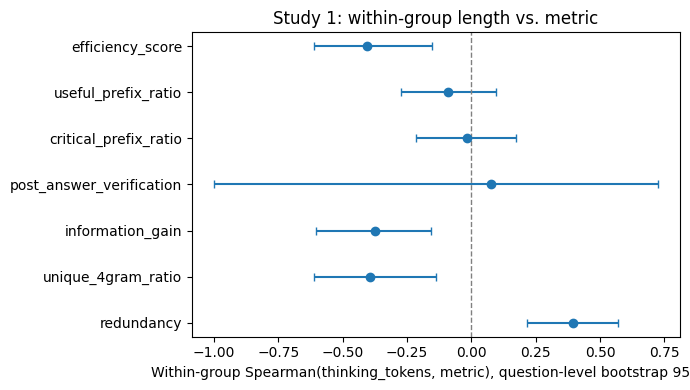

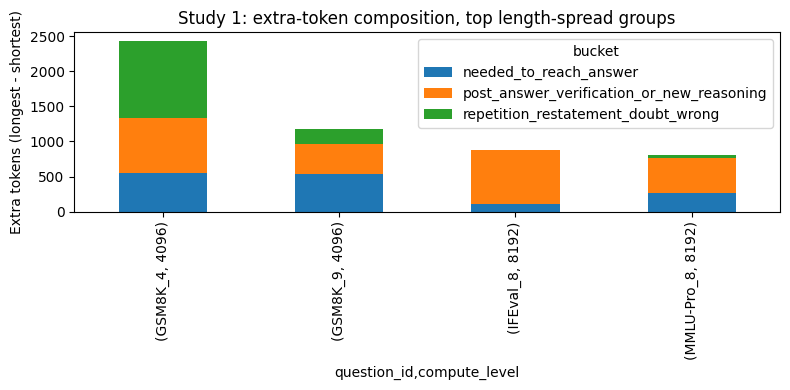

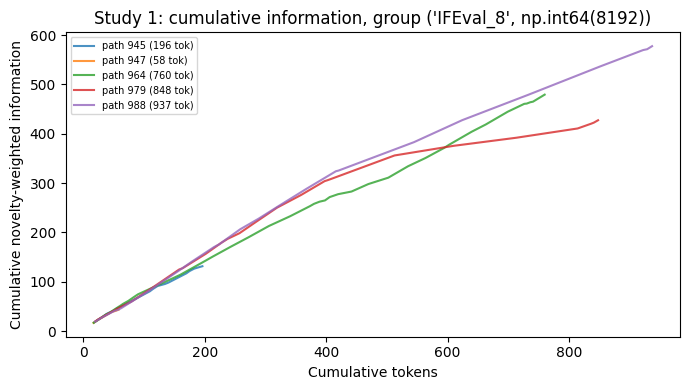

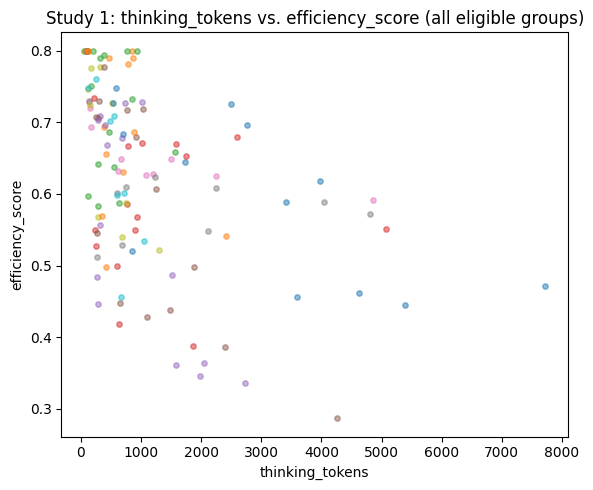

In [55]:
# fig1: forest plot of Spearman(tokens, metric) with question-level bootstrap CI
fig, ax = plt.subplots(figsize=(7, 4))
ys = np.arange(len(within_group_stats))
sm_ = within_group_stats["spearman_mean"]
ax.errorbar(sm_, ys,
            xerr=[sm_ - within_group_stats["spearman_ci_lo"], within_group_stats["spearman_ci_hi"] - sm_],
            fmt="o", capsize=3)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_yticks(ys); ax.set_yticklabels(within_group_stats["metric"])
ax.set_xlabel("Within-group Spearman(thinking_tokens, metric), question-level bootstrap 95% CI")
ax.set_title("Study 1: within-group length vs. metric")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_length_vs_metrics_forest.png", dpi=150)
plt.show()

# fig2: token composition (extra-token buckets) for the top length-spread groups
group_spread = path_metrics.groupby(GK)["thinking_tokens"].agg(["min", "max"])
group_spread["ratio"] = group_spread["max"] / group_spread["min"].clip(lower=1)
top_groups = group_spread.sort_values("ratio", ascending=False).head(CFG["n_viz_groups"]).index
_bk = extra_token_attribution_buckets.set_index(GK)
plot_df = _bk.loc[_bk.index.isin(top_groups)][bucket_cols]
if len(plot_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_df.plot(kind="bar", stacked=True, ax=ax)
    ax.set_ylabel("Extra tokens (longest - shortest)")
    ax.set_title("Study 1: extra-token composition, top length-spread groups")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig2_token_composition.png", dpi=150)
    plt.show()

# fig3: cumulative information curve for a representative group's paths
if len(top_groups) > 0:
    rep_key = top_groups[0]
    rep_rows = path_metrics[(path_metrics["question_id"] == rep_key[0])
                            & (path_metrics["compute_level"] == rep_key[1])]
    fig, ax = plt.subplots(figsize=(7, 4))
    for _, r in rep_rows.iterrows():
        seg_df = segments[segments["row_id"] == r["row_id"]].copy()
        if len(seg_df) == 0:
            continue
        tok = seg_df["n_chars"] / max(seg_df["n_chars"].sum(), 1) * r["total_tokens"]
        cum_info = (seg_df["novelty"].clip(lower=0) * tok).cumsum()
        x = tok.cumsum() if CFG["viz_x_mode"] == "tokens" else np.arange(1, len(seg_df) + 1)
        ax.plot(x, cum_info, label=f"path {int(r['row_id'])} ({int(r['thinking_tokens'])} tok)", alpha=0.8)
    ax.set_xlabel("Cumulative tokens"); ax.set_ylabel("Cumulative novelty-weighted information")
    ax.set_title(f"Study 1: cumulative information, group {rep_key}")
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig3_cumulative_information.png", dpi=150)
    plt.show()

# fig4: thinking_tokens vs efficiency_score (each group in its own colour)
fig, ax = plt.subplots(figsize=(6, 5))
for key, gdf in path_metrics.groupby(GK):
    ax.scatter(gdf["thinking_tokens"], gdf["efficiency_score"], s=15, alpha=0.5)
ax.set_xlabel("thinking_tokens"); ax.set_ylabel("efficiency_score")
ax.set_title("Study 1: thinking_tokens vs. efficiency_score (all eligible groups)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_within_group_scatter.png", dpi=150)
plt.show()

### 1.1.7 Shared sample-level validation (Study 1 portion)

Answer-normalization edge cases and `\boxed{}` coverage over the Study 1 population. (The trajectory-classifier and MC-regex checks follow in Section 1.2.1.)

In [56]:
norm_val_cases = [
    ("$1,234.50", "1234.5"), ("42%", "42"), ("  B  ", "B"), ("3/4", "0.75"),
    ("", None), (None, None), ("Answer: C.", "answer: c"), ("-7", "-7"),
]
norm_val_rows = []
for raw, expected in norm_val_cases:
    got = normalize_answer(raw)
    norm_val_rows.append(dict(raw=raw, expected=expected, got=got, status="PASS" if got == expected else "FAIL"))
norm_val_df = pd.DataFrame(norm_val_rows)
display(norm_val_df)

boxed_coverage = df_all_correct["thinking_text"].str.contains(r"\\boxed\{", regex=True).mean()
print(f"Study 1 population: {boxed_coverage:.1%} of traces contain \\boxed{{}} content")

,raw,expected,got,status
0,"$1,234.50",1234.5,1234.5,PASS
1,42%,42,42,PASS
2,B,B,B,PASS
3,3/4,0.75,0.75,PASS
4,,None,None,PASS
5,None,None,None,PASS
6,Answer: C.,answer: c,answer: c,PASS
7,-7,-7,-7,PASS


Study 1 population: 30.8% of traces contain \boxed{} content


### 1.1.8 Study 1 group summary and outputs

`group_summary.csv` aggregates Study 1 at the group level (n paths, token spread, mean efficiency score) as a compact companion to `path_metrics.csv` and `segments.csv`.

In [57]:
s1_group_summary = (
    path_metrics.groupby(GK)
    .agg(n_paths=("row_id", "size"), mean_tokens=("thinking_tokens", "mean"),
         min_tokens=("thinking_tokens", "min"), max_tokens=("thinking_tokens", "max"),
         mean_efficiency_score=("efficiency_score", "mean"),
         mean_redundancy=("redundancy", "mean"), mean_information_gain=("information_gain", "mean"))
    .reset_index()
)
s1_group_summary["token_ratio"] = s1_group_summary["max_tokens"] / s1_group_summary["min_tokens"].clip(lower=1)

path_metrics.to_csv(BASE_DIR / "path_metrics.csv", index=False)
segments.to_csv(BASE_DIR / "segments.csv", index=False)
s1_group_summary.to_csv(BASE_DIR / "group_summary.csv", index=False)
print(f"Wrote path_metrics.csv ({len(path_metrics)} rows), segments.csv ({len(segments)} rows), "
      f"group_summary.csv ({len(s1_group_summary)} rows)")
s1_group_summary.head()

Wrote path_metrics.csv (130 rows), segments.csv (7987 rows), group_summary.csv (26 rows)


,question_id,compute_level,n_paths,mean_tokens,min_tokens,max_tokens,mean_efficiency_score,mean_redundancy,mean_information_gain,token_ratio
0,GPQA-Diamond_0,8192,5,4368.2,1734,7719,0.520950,0.100650,0.132078,4.451557
1,GSM8K_1,4096,5,861.2,375,2415,0.604270,0.093451,0.249771,6.440000
2,GSM8K_1,8192,5,314.4,112,545,0.662729,0.060427,0.342892,4.866071
3,GSM8K_3,8192,5,950.0,597,1862,0.488414,0.261426,0.194897,3.118928
4,GSM8K_4,4096,5,1721.4,289,2724,0.370130,0.378502,0.022676,9.425606


## 1.2 Study 2: Mixed-Outcome Groups

**Group eligibility.** A group is "mixed" when `0 < n_correct < n_samples` (at least one correct and one incorrect path), with at least `MIN_GROUP_N_S23 = 2` paths. Mixed groups allow contrasting incorrect against correct paths *from the same question and compute level*, controlling for difficulty and budget. We rerun the same shared pipeline in **group mode** (correct and incorrect paths are scored against the same resolved reference), then classify each path's trajectory shape and compute the trajectory-level fields.

In [58]:
import time
mixed_keys = group_stats[
    (group_stats["n_correct"] > 0)
    & (group_stats["n_correct"] < group_stats["n_samples"])
][GK]

s23_eligible_rows = raw_df[
    raw_df["is_correct"].notna()
    & raw_df["thinking_text"].notna()
    & raw_df["thinking_text"].ne("")
]

df_mixed = (
    s23_eligible_rows
    .merge(mixed_keys, on=GK, how="inner")
    .sort_values(GK)
    .reset_index(drop=True)
)

mixed_group_sizes = df_mixed.groupby(GK).size()

mixed_valid_keys = mixed_group_sizes[
    mixed_group_sizes >= MIN_GROUP_N_S23
].index

df_mixed = (
    df_mixed
    .set_index(GK)
    .loc[mixed_valid_keys]
    .reset_index()
)

print(f"Eligible mixed groups: {df_mixed[GK].drop_duplicates().shape[0]}")
print(f"Eligible paths: {len(df_mixed)}")

t0 = time.time()

df_mixed["_own_final_norm"] = df_mixed["thinking_text"].apply(
    own_final_answer
)

print(f"Normalization done in {time.time() - t0:.1f}s")

gold_present_mixed = "gold" in df_mixed.columns

mixed_path_rows = []
mixed_segment_frames = []

groups = list(df_mixed.groupby(GK))
n_groups = len(groups)
n_paths = len(df_mixed)

print(f"Starting analysis: {n_groups} groups, {n_paths} paths")

start_time = time.time()
processed_paths = 0

for group_idx, (key, gdf) in enumerate(groups, 1):

    ref_answer, ref_source = resolve_group_reference(
        gdf,
        gold_present_mixed
    )

    for _, row in gdf.iterrows():

        path_start = time.time()

        seg_df = analyze_path(
            row["thinking_text"],
            ref_answer,
            row["_own_final_norm"]
        )

        traj = classify_trajectory(
            seg_df,
            ref_answer
        )

        n = len(seg_df)

        n_wrong_assert = int(
            (
                seg_df["explicit_answer"].notna()
                & (ref_answer is not None)
                & (seg_df["explicit_answer"] != ref_answer)
            ).sum()
        )

        rec = dict(
            row_id=row["row_id"],
            question_id=key[0],
            compute_level=key[1],
            is_correct=row["is_correct"],
            ref_answer=ref_answer,
            ref_source=ref_source,
            final_answer=row["_own_final_norm"],
            thinking_tokens=row["thinking_tokens"],
            total_tokens=row["thinking_tokens"],
            answer_flips=(
                int(seg_df["answer_flips"].iloc[0])
                if n else 0
            ),
            n_doubt=(
                int(seg_df["n_doubt"].iloc[0])
                if n else 0
            ),
            n_wrong_assert=n_wrong_assert,
            **traj
        )

        mixed_path_rows.append(rec)

        mixed_segment_frames.append(
            seg_df.assign(
                row_id=row["row_id"],
                question_id=key[0],
                compute_level=key[1]
            )
        )

        processed_paths += 1

        if processed_paths % 10 == 0 or processed_paths == n_paths:
            elapsed = time.time() - start_time
            rate = processed_paths / elapsed if elapsed > 0 else 0
            remaining = n_paths - processed_paths
            eta = remaining / rate if rate > 0 else 0
            path_time = time.time() - path_start

            print(
                f"[{processed_paths}/{n_paths}] "
                f"{processed_paths / n_paths:.1%} | "
                f"group {group_idx}/{n_groups} | "
                f"last: {path_time:.2f}s | "
                f"elapsed: {elapsed/60:.1f}m | "
                f"ETA: {eta/60:.1f}m"
            )

mixed_path_metrics = pd.DataFrame(mixed_path_rows)

mixed_segments = (
    pd.concat(mixed_segment_frames, ignore_index=True)
    if mixed_segment_frames
    else pd.DataFrame()
)

total_time = time.time() - start_time

print()
print(
    f"Study 2: "
    f"{df_mixed[GK].drop_duplicates().shape[0]} eligible mixed groups, "
    f"{len(mixed_path_metrics)} paths"
)
print(f"Segment rows: {len(mixed_segments)}")
print(f"Total time: {total_time / 60:.1f} minutes")

if processed_paths:
    print(f"Average time/path: {total_time / processed_paths:.3f}s")

mixed_path_metrics.head(3)

Eligible mixed groups: 214
Eligible paths: 1061
Normalization done in 4.4s
Starting analysis: 214 groups, 1061 paths
[10/1061] 0.9% | group 2/214 | last: 0.39s | elapsed: 0.1m | ETA: 5.7m
[20/1061] 1.9% | group 4/214 | last: 3.36s | elapsed: 0.5m | ETA: 26.0m
[30/1061] 2.8% | group 6/214 | last: 0.59s | elapsed: 0.6m | ETA: 18.9m
[40/1061] 3.8% | group 8/214 | last: 2.23s | elapsed: 0.8m | ETA: 19.9m
[50/1061] 4.7% | group 10/214 | last: 0.13s | elapsed: 1.1m | ETA: 21.5m
[60/1061] 5.7% | group 12/214 | last: 0.57s | elapsed: 1.1m | ETA: 18.8m
[70/1061] 6.6% | group 14/214 | last: 0.84s | elapsed: 1.2m | ETA: 17.3m
[80/1061] 7.5% | group 16/214 | last: 2.07s | elapsed: 1.6m | ETA: 19.2m
[90/1061] 8.5% | group 18/214 | last: 0.39s | elapsed: 1.6m | ETA: 17.2m
[100/1061] 9.4% | group 20/214 | last: 0.56s | elapsed: 1.6m | ETA: 15.6m
[110/1061] 10.4% | group 22/214 | last: 0.41s | elapsed: 1.7m | ETA: 14.5m
[120/1061] 11.3% | group 24/214 | last: 0.26s | elapsed: 1.8m | ETA: 14.0m
[130/10

,row_id,question_id,compute_level,is_correct,ref_answer,ref_source,final_answer,thinking_tokens,total_tokens,answer_flips,n_doubt,n_wrong_assert,trajectory_shape,divergence_idx,divergence_frac,divergence_next_label,ever_correct,ends_correct,first_correct_frac
0,1981,AIME2025_0,512,False,70,gold,9,510,510,0,2,0,never_found,NaN,NaN,None,False,False,NaN
1,1987,AIME2025_0,512,True,70,gold,7,511,511,0,4,1,never_found,NaN,NaN,None,False,False,NaN
2,1990,AIME2025_0,512,True,70,gold,7,511,511,0,1,0,never_found,NaN,NaN,None,False,False,NaN


## 1.3 Study 3: All-Wrong Groups

**Group eligibility.** A group is "all-wrong" when `n_correct == 0`, with at least `MIN_GROUP_N_S23 = 2` paths. Study 3 runs the identical shared pipeline and trajectory classification but, because no correct comparator exists, is restricted to *within-path* trajectory composition. No incorrect-vs-correct timing contrast or cross-path grounding is computed here (those are Study 2 only).

In [59]:

allwrong_keys = group_stats[
    group_stats["n_correct"] == 0
][GK]

df_allwrong = (
    s23_eligible_rows
    .merge(allwrong_keys, on=GK, how="inner")
    .sort_values(GK)
    .reset_index(drop=True)
)

allwrong_group_sizes = df_allwrong.groupby(GK).size()

allwrong_valid_keys = allwrong_group_sizes[
    allwrong_group_sizes >= MIN_GROUP_N_S23
].index

df_allwrong = (
    df_allwrong
    .set_index(GK)
    .loc[allwrong_valid_keys]
    .reset_index()
)

print(
    f"Eligible all-wrong groups: "
    f"{df_allwrong[GK].drop_duplicates().shape[0]}"
)
print(f"Eligible paths: {len(df_allwrong)}")

t0 = time.time()

df_allwrong["_own_final_norm"] = df_allwrong["thinking_text"].apply(
    own_final_answer
)

print(f"Normalization done in {time.time() - t0:.1f}s")

gold_present_aw = "gold" in df_allwrong.columns

allwrong_path_rows = []
allwrong_segment_frames = []

groups = list(df_allwrong.groupby(GK))
n_groups = len(groups)
n_paths = len(df_allwrong)

print(f"Starting analysis: {n_groups} groups, {n_paths} paths")

start_time = time.time()
processed_paths = 0

for group_idx, (key, gdf) in enumerate(groups, 1):

    ref_answer, ref_source = resolve_group_reference(
        gdf,
        gold_present_aw
    )

    for _, row in gdf.iterrows():

        path_start = time.time()

        seg_df = analyze_path(
            row["thinking_text"],
            ref_answer,
            row["_own_final_norm"]
        )

        traj = classify_trajectory(
            seg_df,
            ref_answer
        )

        rec = dict(
            row_id=row["row_id"],
            question_id=key[0],
            compute_level=key[1],
            is_correct=row["is_correct"],
            ref_answer=ref_answer,
            ref_source=ref_source,
            final_answer=row["_own_final_norm"],
            thinking_tokens=row["thinking_tokens"],
            total_tokens=row["thinking_tokens"],
            **traj
        )

        allwrong_path_rows.append(rec)

        allwrong_segment_frames.append(
            seg_df.assign(
                row_id=row["row_id"],
                question_id=key[0],
                compute_level=key[1]
            )
        )

        processed_paths += 1

        if processed_paths % 10 == 0 or processed_paths == n_paths:
            elapsed = time.time() - start_time
            rate = processed_paths / elapsed if elapsed > 0 else 0
            remaining = n_paths - processed_paths
            eta = remaining / rate if rate > 0 else 0
            path_time = time.time() - path_start

            print(
                f"[{processed_paths}/{n_paths}] "
                f"{processed_paths / n_paths:.1%} | "
                f"group {group_idx}/{n_groups} | "
                f"last: {path_time:.2f}s | "
                f"elapsed: {elapsed/60:.1f}m | "
                f"ETA: {eta/60:.1f}m"
            )

allwrong_path_metrics = pd.DataFrame(
    allwrong_path_rows
)

allwrong_segments = (
    pd.concat(
        allwrong_segment_frames,
        ignore_index=True
    )
    if allwrong_segment_frames
    else pd.DataFrame()
)

total_time = time.time() - start_time

print()
print(
    f"Study 3: "
    f"{df_allwrong[GK].drop_duplicates().shape[0]} "
    f"eligible all-wrong groups, "
    f"{len(allwrong_path_metrics)} paths"
)
print(f"Segment rows: {len(allwrong_segments)}")
print(f"Total time: {total_time / 60:.1f} minutes")

if processed_paths:
    print(
        f"Average time/path: "
        f"{total_time / processed_paths:.3f}s"
    )

allwrong_path_metrics.head(3)

Eligible all-wrong groups: 133
Eligible paths: 663
Normalization done in 2.2s
Starting analysis: 133 groups, 663 paths
[10/663] 1.5% | group 2/133 | last: 0.24s | elapsed: 0.0m | ETA: 1.9m
[20/663] 3.0% | group 4/133 | last: 0.57s | elapsed: 0.1m | ETA: 3.1m
[30/663] 4.5% | group 6/133 | last: 0.34s | elapsed: 0.2m | ETA: 4.3m
[40/663] 6.0% | group 8/133 | last: 0.19s | elapsed: 0.3m | ETA: 4.7m
[50/663] 7.5% | group 10/133 | last: 0.54s | elapsed: 0.4m | ETA: 4.7m
[60/663] 9.0% | group 12/133 | last: 0.32s | elapsed: 0.4m | ETA: 4.3m
[70/663] 10.6% | group 14/133 | last: 1.21s | elapsed: 0.6m | ETA: 5.1m
[80/663] 12.1% | group 16/133 | last: 0.16s | elapsed: 0.8m | ETA: 6.0m
[90/663] 13.6% | group 18/133 | last: 0.52s | elapsed: 0.9m | ETA: 5.8m
[100/663] 15.1% | group 20/133 | last: 2.15s | elapsed: 1.2m | ETA: 6.6m
[110/663] 16.6% | group 22/133 | last: 0.13s | elapsed: 1.5m | ETA: 7.4m
[120/663] 18.1% | group 24/133 | last: 0.12s | elapsed: 1.5m | ETA: 7.0m
[130/663] 19.6% | group 

,row_id,question_id,compute_level,is_correct,ref_answer,ref_source,final_answer,thinking_tokens,total_tokens,trajectory_shape,divergence_idx,divergence_frac,divergence_next_label,ever_correct,ends_correct,first_correct_frac
0,1982,AIME2025_0,256,False,70,gold,7,255,255,never_found,NaN,NaN,None,False,False,NaN
1,1991,AIME2025_0,256,False,70,gold,7,255,255,never_found,NaN,NaN,None,False,False,NaN
2,1992,AIME2025_0,256,False,70,gold,7,255,255,never_found,NaN,NaN,None,False,False,NaN


### 1.2.1 Shared sample-level validation (Studies 2/3)

Before trusting the trajectory classifier on real data, we run it on four synthetic traces constructed to exercise each trajectory class and check `expected == detected`. We also report MC-regex coverage by benchmark (when a benchmark column exists), `ref_source` / `answer_detect` distributions, and a label spot-check sample for manual audit.

In [60]:
synthetic_cases = {
    "never_found": (
        "Let's think about this. The value seems close to 12. "
        "Actually maybe it's 15. I'm not fully sure, but I'll go with 15."
    ),
    "stable_from_first": (
        "The answer is 42. Let me double check: 42 satisfies all constraints. "
        "Confirmed, the final answer is 42."
    ),
    "found_then_lost": (
        "First, the answer is 7. Wait, let me reconsider this calculation. "
        "Hmm, actually recomputing gives 9. So the final answer is 9."
    ),
    "wavered_but_recovered": (
        "The answer is 3. Wait, that's wrong, so the answer is 5. "
        "Hmm, actually on reflection, the answer is 3 after all. "
        "Final answer: 3."
    ),
}

synthetic_gold = {
    "never_found": "99",
    "stable_from_first": "42",
    "found_then_lost": "7",
    "wavered_but_recovered": "3",
}

trajectory_check_rows = []

for name, text in synthetic_cases.items():
    seg_df = analyze_path(
        text,
        synthetic_gold[name],
        own_final_answer(text),
    )

    traj = classify_trajectory(
        seg_df,
        synthetic_gold[name],
    )

    trajectory_check_rows.append({
        "case": name,
        "expected": name,
        "detected": traj["trajectory_shape"],
        "status": (
            "PASS"
            if traj["trajectory_shape"] == name
            else "FAIL"
        ),
    })

divergence_classifier_checks = pd.DataFrame(
    trajectory_check_rows
)

divergence_classifier_checks.to_csv(
    BASE_DIR / "divergence_classifier_checks.csv",
    index=False,
)

display(divergence_classifier_checks)

if BENCHMARK_COL in raw_df.columns:
    mc_bench = raw_df[
        raw_df[BENCHMARK_COL].astype(str).str.contains(
            "MMLU-Pro|MMLU-Redux|GPQA-Diamond",
            case=False,
            regex=True,
            na=False,
        )
    ].copy()

    if len(mc_bench):
        mc_coverage = (
            mc_bench["thinking_text"]
            .fillna("")
            .astype(str)
            .apply(
                lambda t: any(
                    c[2]
                    for s in segment_text(t)[:5]
                    for c in segment_raw_features(s)["candidates"]
                )
            )
            .mean()
        )

        print(
            f"MC-regex coverage over first 5 segments, "
            f"MMLU-Pro/Redux/GPQA-Diamond rows: {mc_coverage:.1%}"
        )
    else:
        print(
            "No MMLU-Pro / MMLU-Redux / GPQA-Diamond rows found."
        )

dead_branch_count = int(
    raw_df["is_correct"].isna().sum()
)

print(
    f"Rows with unresolved is_correct (dead branch): "
    f"{dead_branch_count}"
)

ref_source_dist = pd.concat(
    [
        mixed_path_metrics["ref_source"],
        allwrong_path_metrics["ref_source"],
    ],
    ignore_index=True,
).value_counts()

print("\nref_source distribution (Studies 2+3):")
print(ref_source_dist)

answer_detect_dist = pd.concat(
    [
        mixed_path_metrics["final_answer"].notna(),
        allwrong_path_metrics["final_answer"].notna(),
    ],
    ignore_index=True,
).value_counts()

print("\nanswer_detect distribution (Studies 2+3):")
print(answer_detect_dist)

if len(mixed_segments):
    label_spot_check = (
        mixed_segments
        .sample(
            min(10, len(mixed_segments)),
            random_state=CFG["seed"],
        )[
            [
                "row_id",
                "seg_idx",
                "text",
                "label",
            ]
        ]
    )

    display(label_spot_check)
else:
    print("mixed_segments is empty; no label spot check available.")

,case,expected,detected,status
0,never_found,never_found,never_found,PASS
1,stable_from_first,stable_from_first,stable_from_first,PASS
2,found_then_lost,found_then_lost,found_then_lost,PASS
3,wavered_but_recovered,wavered_but_recovered,wavered_but_recovered,PASS


MC-regex coverage over first 5 segments, MMLU-Pro/Redux/GPQA-Diamond rows: 63.2%
Rows with unresolved is_correct (dead branch): 0

ref_source distribution (Studies 2+3):
ref_source
gold         1212
consensus     300
own_final     212
Name: count, dtype: int64

answer_detect distribution (Studies 2+3):
final_answer
True     1723
False       1
Name: count, dtype: int64


,row_id,seg_idx,text,label
68483,2955,159,"So for the group {1,2}, the number of pairs is...",new_reasoning
58745,2865,165,"So in this case, returning True would mean tha...",new_reasoning
73081,1092,45,"Yes, that's correct.)",new_reasoning
59335,2868,308,"- Then, simulate the game using memoization, c...",verification
3729,2031,0,"Okay, so I need to figure out how many ways th...",new_reasoning
88916,1730,40,* D. Customer participation and environmenta...,repetition
14664,2407,164,"Actually, the conjugation is between the carbo...",new_reasoning
2896,2121,49,"AF = 13, FG = 52, GC = 26.",repetition
16685,2486,201,Conjugate addition: Nu- adds to C2?,new_reasoning
76667,1311,36,But maybe another set of numbers.,new_reasoning


### 1.2.2 Study 2 analyses

* **Correctness cross-tab**: `trajectory_shape x is_correct`, a sanity view of how much trajectory shape predicts outcome.
* **Ends-correct agreement**: how often the classifier's `ends_correct` flag agrees with the ground-truth `is_correct` (a consistency check on the classifier, not a new outcome measure).
* **Timing contrast**: within each mixed group, `mean(metric | incorrect) - mean(metric | correct)` for `first_correct_frac`, `n_doubt`, `answer_flips`, `n_wrong_assert`; averaged to the question level and bootstrapped over questions (same machinery as 1.1.4). No pairwise sequence alignment is performed.

In [61]:
correctness_crosstab = pd.crosstab(mixed_path_metrics["trajectory_shape"], mixed_path_metrics["is_correct"])
display(correctness_crosstab)

ends_correct_agreement = (mixed_path_metrics["ends_correct"] == mixed_path_metrics["is_correct"]).mean()
print(f"ends_correct vs is_correct agreement: {ends_correct_agreement:.1%}")

TIMING_METRICS = ["first_correct_frac", "n_doubt", "answer_flips", "n_wrong_assert"]
timing_rows = []
for key, gdf in mixed_path_metrics.groupby(GK):
    correct = gdf[gdf["is_correct"] == True]
    incorrect = gdf[gdf["is_correct"] == False]
    if len(correct) == 0 or len(incorrect) == 0:
        continue
    row = dict(question_id=key[0], compute_level=key[1])
    for m in TIMING_METRICS:
        row[m] = incorrect[m].mean() - correct[m].mean()
    timing_rows.append(row)
timing_group = pd.DataFrame(timing_rows)
timing_question = timing_group.groupby("question_id").mean(numeric_only=True)

timing_contrast_rows = []
for m in TIMING_METRICS:
    mean_, lo, hi, p = bootstrap_question_level(timing_question[m])
    timing_contrast_rows.append(dict(metric=m, mean_diff_incorrect_minus_correct=mean_,
                                     ci_lo=lo, ci_hi=hi, bootstrap_p=p))
divergence_timing_contrast = pd.DataFrame(timing_contrast_rows)
divergence_timing_contrast.to_csv(BASE_DIR / "divergence_timing_contrast.csv", index=False)
divergence_timing_contrast

is_correct,False,True
trajectory_shape,,
found_then_lost,1,4
never_found,467,446
stable_from_first,21,116
wavered_but_recovered,2,4


ends_correct vs is_correct agreement: 55.4%


,metric,mean_diff_incorrect_minus_correct,ci_lo,ci_hi,bootstrap_p
0,first_correct_frac,-0.039066,-0.159744,0.081457,0.536
1,n_doubt,0.349552,-0.411351,1.276828,0.446
2,answer_flips,-0.040457,-0.074196,-0.008869,0.010
3,n_wrong_assert,0.015121,-0.061986,0.083976,0.626


### 1.2.3 Study 2 cross-path grounding (exploratory)

For every incorrect path in a mixed group, we compare each of its segments against every segment of the group's correct paths using maximum SBERT cosine similarity. This is an exploratory measure of how "grounded" an incorrect path stays in content that also appears in correct reasoning, not a claim of causal or temporal alignment between paths.

In [ ]:
grounding_rows = []
for key, gdf in tqdm(mixed_path_metrics.groupby(GK), desc="grounding groups",
                     total=mixed_path_metrics[GK].drop_duplicates().shape[0]):
    correct_row_ids = gdf[gdf["is_correct"] == True]["row_id"].tolist()
    incorrect_row_ids = gdf[gdf["is_correct"] == False]["row_id"].tolist()
    if not correct_row_ids or not incorrect_row_ids:
        continue
    correct_segs = mixed_segments[mixed_segments["row_id"].isin(correct_row_ids)]
    if len(correct_segs) == 0:
        continue
    correct_embs = embed_segments(correct_segs["text"].tolist())
    for rid in incorrect_row_ids:
        inc_segs = mixed_segments[mixed_segments["row_id"] == rid].reset_index(drop=True)
        if len(inc_segs) == 0:
            continue
        inc_embs = embed_segments(inc_segs["text"].tolist())
        sims = cosine_similarity(inc_embs, correct_embs).max(axis=1)
        n = len(inc_segs)
        div_row = mixed_path_metrics[mixed_path_metrics["row_id"] == rid].iloc[0]
        for i in range(n):
            grounding_rows.append(dict(
                question_id=key[0], compute_level=key[1], row_id=rid,
                norm_position=i / max(n - 1, 1), max_sim_to_correct=sims[i],
                is_divergence_point=(not pd.isna(div_row["divergence_idx"])) and (i == int(div_row["divergence_idx"])),
            ))
cross_path_grounding = pd.DataFrame(grounding_rows)
print(f"Cross-path grounding: {len(cross_path_grounding)} (incorrect-path segment) comparisons")
cross_path_grounding.head()

### 1.3.1 Study 3 analysis

With no correct comparator available, Study 3 reports trajectory composition within all-wrong groups, with the `never_found` and `found_then_lost` rates called out since they are the most diagnostic of *why* a group failed entirely (never engaged the right answer at all, vs. touched it and drifted away).

In [63]:
allwrong_composition = allwrong_path_metrics["trajectory_shape"].value_counts(normalize=True)
print("Study 3 trajectory composition (share of all-wrong paths):")
display(allwrong_composition)
print(f"never_found rate: {allwrong_composition.get('never_found', 0.0):.1%}")
print(f"found_then_lost rate: {allwrong_composition.get('found_then_lost', 0.0):.1%}")

Study 3 trajectory composition (share of all-wrong paths):


trajectory_shape
never_found          0.911011
stable_from_first    0.085973
found_then_lost      0.003017
Name: proportion, dtype: float64

never_found rate: 91.1%
found_then_lost rate: 0.3%


## 1.4 Study 2/3 figures and outputs

Three figures: divergence position (where in the trace found-then-lost paths diverge), cross-path grounding (incorrect-path similarity to correct reasoning over normalized position), and trajectory composition (Study 2 vs Study 3). For the representative found-then-lost example we pick the path from the *middle* of the `thinking_tokens` ordering rather than an extreme, so the plotted example is typical rather than a cherry-picked outlier.

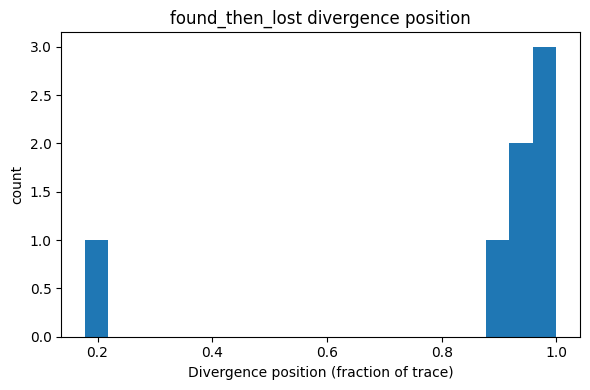

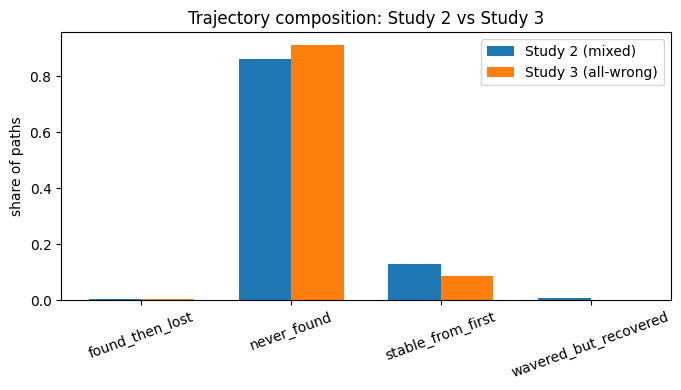

Wrote mixed_path_metrics.csv, mixed_segments.csv, allwrong_path_metrics.csv, allwrong_segments.csv


In [64]:
# fig5: divergence position histogram (found_then_lost paths, Studies 2 + 3)
fig, ax = plt.subplots(figsize=(6, 4))
div_fracs = pd.concat([mixed_path_metrics["divergence_frac"], allwrong_path_metrics["divergence_frac"]]).dropna()
ax.hist(div_fracs, bins=20)
ax.set_xlabel("Divergence position (fraction of trace)"); ax.set_ylabel("count")
ax.set_title("found_then_lost divergence position")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_divergence_position.png", dpi=150)
plt.show()

# fig6: cross-path grounding for a representative found_then_lost path (middle of token ordering)
ftl = mixed_path_metrics[mixed_path_metrics["trajectory_shape"] == "found_then_lost"].sort_values("thinking_tokens")
if len(ftl) > 0:
    mid_row = ftl.iloc[len(ftl) // 2]
    rep_ground = cross_path_grounding[cross_path_grounding["row_id"] == mid_row["row_id"]]
    if len(rep_ground) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(rep_ground["norm_position"], rep_ground["max_sim_to_correct"], marker="o", markersize=3)
        div_pt = rep_ground[rep_ground["is_divergence_point"]]
        if len(div_pt) > 0:
            ax.axvline(div_pt["norm_position"].iloc[0], color="red", linestyle="--", label="divergence")
            ax.legend()
        ax.set_xlabel("Normalized trace position"); ax.set_ylabel("Max similarity to a correct-path segment")
        ax.set_title(f"Study 2: cross-path grounding, path {int(mid_row['row_id'])}")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "fig6_cross_path_grounding.png", dpi=150)
        plt.show()

# fig7: trajectory composition, Study 2 vs Study 3
fig, ax = plt.subplots(figsize=(7, 4))
comp2 = mixed_path_metrics["trajectory_shape"].value_counts(normalize=True)
comp3 = allwrong_path_metrics["trajectory_shape"].value_counts(normalize=True)
shapes = sorted(set(comp2.index) | set(comp3.index))
x = np.arange(len(shapes)); w = 0.35
ax.bar(x - w / 2, [comp2.get(s, 0) for s in shapes], width=w, label="Study 2 (mixed)")
ax.bar(x + w / 2, [comp3.get(s, 0) for s in shapes], width=w, label="Study 3 (all-wrong)")
ax.set_xticks(x); ax.set_xticklabels(shapes, rotation=20)
ax.set_ylabel("share of paths"); ax.set_title("Trajectory composition: Study 2 vs Study 3")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_trajectory_composition.png", dpi=150)
plt.show()

mixed_path_metrics.to_csv(BASE_DIR / "mixed_path_metrics.csv", index=False)
mixed_segments.to_csv(BASE_DIR / "mixed_segments.csv", index=False)
allwrong_path_metrics.to_csv(BASE_DIR / "allwrong_path_metrics.csv", index=False)
allwrong_segments.to_csv(BASE_DIR / "allwrong_segments.csv", index=False)
print("Wrote mixed_path_metrics.csv, mixed_segments.csv, allwrong_path_metrics.csv, allwrong_segments.csv")

# 2. OVER BENCHMARKS ANALYSIS

This section operates on the **full raw dataframe** (not restricted to Studies 1-3's eligible subsets). For each benchmark we compute accuracy at every compute level, plot the accuracy-vs-compute curve, and apply Kneedle (concave, increasing) to identify a "knee" compute level, i.e. the point past which more compute yields diminishing accuracy returns. If Kneedle finds no knee we report `None` rather than inventing a fallback.

## 2.1 Accuracy by Compute Level for Each Benchmark

In [ ]:
assert BENCHMARK_COL in raw_df.columns, (
    f"Benchmark column '{BENCHMARK_COL}' not found in raw data; set BENCHMARK_COL "
    f"to the actual benchmark identifier column before running this section."
)

# order compute levels numerically when possible (non-numeric levels go last)
raw_df["compute_level_num"] = pd.to_numeric(raw_df["compute_level"], errors="coerce")
_compute_order = (
    raw_df[["compute_level", "compute_level_num"]].drop_duplicates()
    .sort_values("compute_level_num", na_position="last")["compute_level"].tolist()
)
# String-typed mirror of _compute_order. Several downstream frames cast their
# "compute_level" column to str (e.g. benchmark_accuracy_out, compute_level_agg,
# difficulty_accuracy_out) for CSV export / plotting. Reusing the *original*
# (numeric) _compute_order as `categories=`/`columns=` against those str columns
# silently produces all-NaN (no type matches), which is exactly the bug behind
# the fully-NaN benchmark/difficulty tables and the "nan" x-axis on fig12.
# Use _compute_order_str wherever the column being categorized/reindexed has
# already been cast to str.
_compute_order_str = [str(c) for c in _compute_order]

benchmark_accuracy = (
    raw_df.dropna(subset=["is_correct"])
    .groupby([BENCHMARK_COL, "compute_level"])["is_correct"]
    .agg(accuracy="mean", n="size").reset_index()
)
benchmark_accuracy["compute_level"] = pd.Categorical(
    benchmark_accuracy["compute_level"], categories=_compute_order, ordered=True
)
benchmark_accuracy = benchmark_accuracy.sort_values([BENCHMARK_COL, "compute_level"])
benchmark_accuracy.head(10)

### 2.2 Benchmark Accuracy Curves

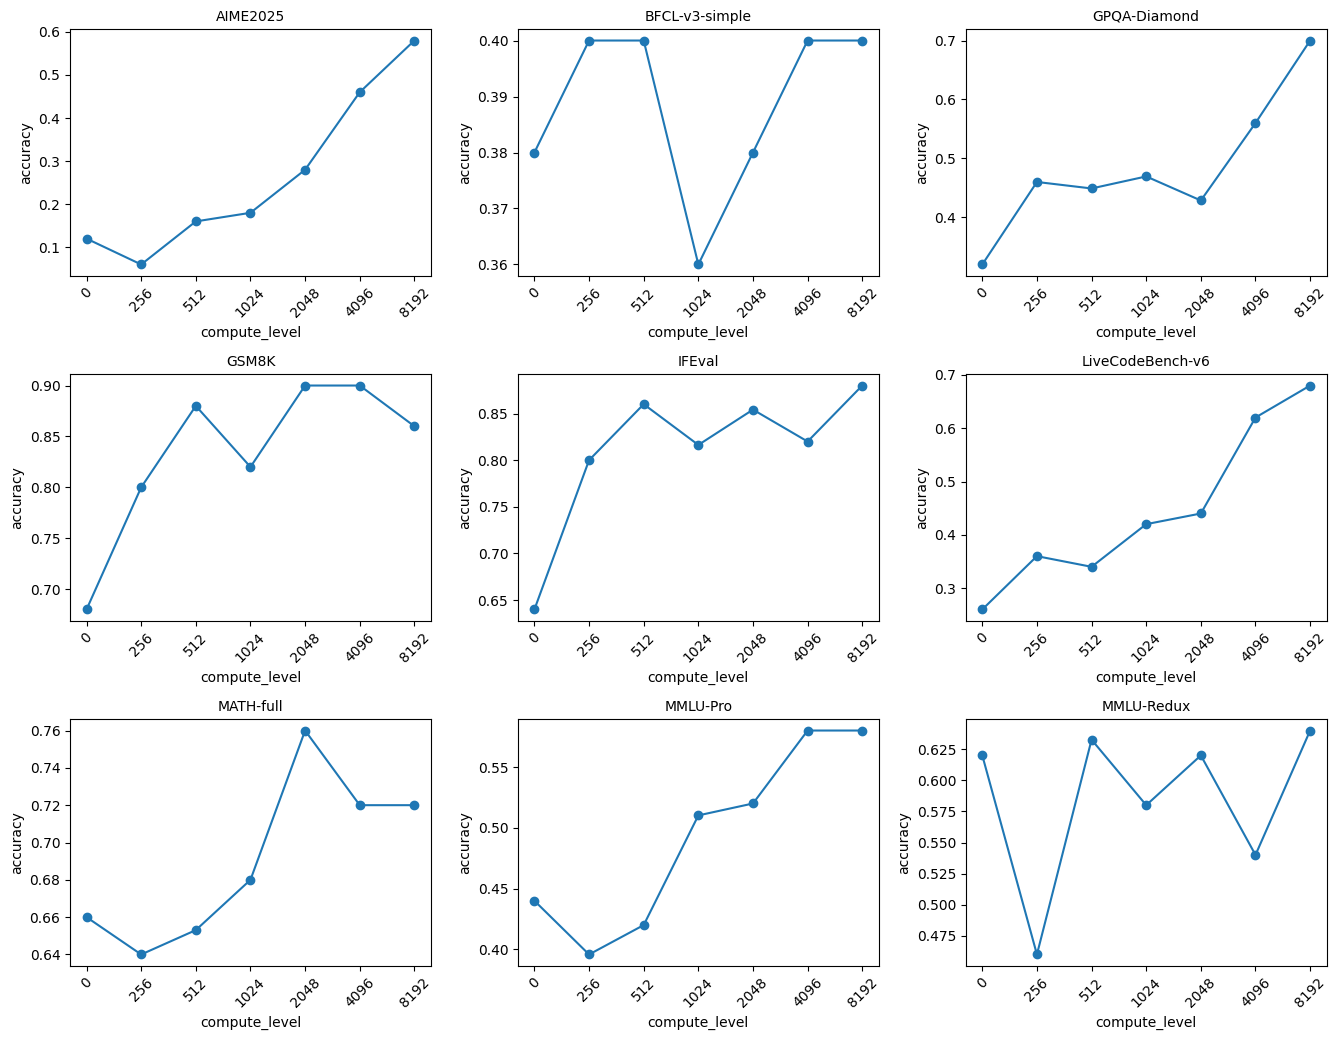

In [66]:
benchmarks = sorted(benchmark_accuracy[BENCHMARK_COL].dropna().unique())
n_bench = len(benchmarks)
ncols = min(3, n_bench) if n_bench > 0 else 1
nrows = math.ceil(n_bench / ncols) if n_bench > 0 else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows), squeeze=False)
for i, bench in enumerate(benchmarks):
    ax = axes[i // ncols][i % ncols]
    sub = benchmark_accuracy[benchmark_accuracy[BENCHMARK_COL] == bench]
    ax.plot(sub["compute_level"].astype(str), sub["accuracy"], marker="o")
    ax.set_title(str(bench), fontsize=10)
    ax.set_xlabel("compute_level"); ax.set_ylabel("accuracy")
    ax.tick_params(axis="x", rotation=45)
for j in range(n_bench, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_benchmark_accuracy_curves.png", dpi=150)
plt.show()

### 2.3 Kneedle-Based Optimal Compute Level

Kneedle is applied per benchmark on the compute-level-ordered accuracy curve with `curve="concave", direction="increasing"`. The x-axis is the **ordinal position** of the compute level (0, 1, 2, ...), so unevenly spaced levels are treated as equally spaced. The same function and convention are reused in Sections 3 and 4, so results are directly comparable. A curve with fewer than 3 levels, or with no detected knee, gets `None`.

In [ ]:
def kneedle_optimal_level(x_labels, y_values):
    """Kneedle knee on ordinal x positions; None if not found.

    Tries curve="concave" first, then falls back to curve="convex" (accuracy-vs-
    compute curves are often convex-then-flattening near the low end, which the
    pure-concave assumption misses). A knee detected at the very first or very
    last position is treated as degenerate -- a known kneedle failure mode on
    short (<10 point) or non-monotonic curves, where it defaults to a boundary
    point instead of finding a real interior elbow -- and reported as None
    rather than a misleading value.
    """
    if len(x_labels) < 3:
        return None
    x = np.arange(len(x_labels))
    for curve in ("concave", "convex"):
        try:
            kl = KneeLocator(x, y_values, curve=curve, direction="increasing")
        except Exception:
            continue
        if kl.knee is None:
            continue
        knee_pos = int(kl.knee)
        if knee_pos in (0, len(x_labels) - 1):
            continue  # degenerate / boundary "knee" -- not a real interior elbow
        return x_labels[knee_pos]
    return None

bench_knee_rows = []
for bench in benchmarks:
    sub = benchmark_accuracy[benchmark_accuracy[BENCHMARK_COL] == bench].dropna(subset=["accuracy"])
    knee = kneedle_optimal_level(sub["compute_level"].astype(str).tolist(), sub["accuracy"].tolist())
    bench_knee_rows.append(dict(benchmark=bench, kneedle_optimal_compute_level=knee))
benchmark_kneedle = pd.DataFrame(bench_knee_rows)
benchmark_kneedle

### 2.4 Benchmark-Level Outputs

In [68]:
benchmark_accuracy_out = benchmark_accuracy.copy()
benchmark_accuracy_out["compute_level"] = benchmark_accuracy_out["compute_level"].astype(str)
benchmark_accuracy_out.to_csv(BASE_DIR / "benchmark_accuracy_by_compute_level.csv", index=False)
benchmark_kneedle.to_csv(BASE_DIR / "benchmark_kneedle_optimal_compute_level.csv", index=False)
print("Wrote benchmark_accuracy_by_compute_level.csv, benchmark_kneedle_optimal_compute_level.csv")

Wrote benchmark_accuracy_by_compute_level.csv, benchmark_kneedle_optimal_compute_level.csv


# 3. OVER COMPUTE LEVEL ANALYSIS

This section also operates on the **full raw dataframe**. The goal is a single accuracy-vs-compute curve across benchmarks that is **not dominated by benchmark sample size**.

A naive approach (pool every sample and compute one accuracy per compute level) would let large benchmarks dominate. Instead:

1. compute accuracy per (benchmark, compute level), already done in 2.1,
2. **normalize within each benchmark** across its compute levels (min-max),
3. average the normalized curves **equally across benchmarks**.

Raw benchmark accuracy (Section 2) and the normalized aggregate (this section) are kept strictly separate: normalized values are only meaningful as a *shape* (where along the compute axis gains saturate), not as accuracy.

## 3.1 Benchmark-Level Normalization

```
normalized_accuracy = (accuracy - benchmark_min_accuracy) / (benchmark_max_accuracy - benchmark_min_accuracy)
```

A benchmark whose accuracy is constant across all compute levels has an undefined normalized trend (0/0). It is **excluded** from the normalized aggregate rather than assigned an invented value (0, 0.5 or 1).

In [69]:
# ---- 3.1 Benchmark-level min-max normalization ----------------------------
bench_acc = benchmark_accuracy_out.copy()   # raw accuracy per (benchmark, compute_level); compute_level is str

bench_range = (
    bench_acc.groupby(BENCHMARK_COL)["accuracy"]
    .agg(bench_min="min", bench_max="max").reset_index()
)
bench_range["acc_range"] = bench_range["bench_max"] - bench_range["bench_min"]
bench_range["is_constant"] = np.isclose(bench_range["acc_range"], 0.0)

bench_norm = bench_acc.merge(bench_range, on=BENCHMARK_COL, how="left")
bench_norm["normalized_accuracy"] = np.where(
    bench_norm["is_constant"],
    np.nan,
    (bench_norm["accuracy"] - bench_norm["bench_min"]) / bench_norm["acc_range"].replace(0, np.nan),
)

constant_benchmarks = bench_range.loc[bench_range["is_constant"], BENCHMARK_COL].tolist()
print(f"{bench_range.shape[0]} benchmarks | "
      f"{len(constant_benchmarks)} constant-accuracy benchmark(s) excluded from the normalized aggregate: "
      f"{constant_benchmarks if constant_benchmarks else 'none'}")
bench_norm.head(10)

9 benchmarks | 0 constant-accuracy benchmark(s) excluded from the normalized aggregate: none


,benchmark,compute_level,accuracy,n,bench_min,bench_max,acc_range,is_constant,normalized_accuracy
0,AIME2025,0,0.12,50,0.06,0.58,0.52,False,0.115385
1,AIME2025,256,0.06,50,0.06,0.58,0.52,False,0.000000
2,AIME2025,512,0.16,50,0.06,0.58,0.52,False,0.192308
3,AIME2025,1024,0.18,50,0.06,0.58,0.52,False,0.230769
4,AIME2025,2048,0.28,50,0.06,0.58,0.52,False,0.423077
5,AIME2025,4096,0.46,50,0.06,0.58,0.52,False,0.769231
6,AIME2025,8192,0.58,50,0.06,0.58,0.52,False,1.000000
7,BFCL-v3-simple,0,0.38,50,0.36,0.40,0.04,False,0.500000
8,BFCL-v3-simple,256,0.40,50,0.36,0.40,0.04,False,1.000000
9,BFCL-v3-simple,512,0.40,50,0.36,0.40,0.04,False,1.000000


### 3.2 Aggregate Accuracy by Compute Level

For each compute level, the aggregate is the **unweighted mean of the normalized accuracies across benchmarks** that have a defined normalized value at that level (each benchmark gets one equal vote). `n_benchmarks` reports how many benchmarks contributed at each level, so uneven coverage is visible rather than hidden.

In [ ]:
# ---- 3.2 Equal-weight aggregate of normalized benchmark curves --------------
compute_level_agg = (
    bench_norm.dropna(subset=["normalized_accuracy"])
    .groupby("compute_level")
    .agg(mean_normalized_accuracy=("normalized_accuracy", "mean"),
         sd_normalized_accuracy=("normalized_accuracy", "std"),
         n_benchmarks=(BENCHMARK_COL, "nunique"))
    .reset_index()
)
compute_level_agg["compute_level"] = pd.Categorical(
    compute_level_agg["compute_level"], categories=_compute_order_str, ordered=True
)
compute_level_agg = compute_level_agg.sort_values("compute_level").reset_index(drop=True)
compute_level_agg["compute_level"] = compute_level_agg["compute_level"].astype(str)
compute_level_agg

### 3.3 Kneedle-Based Optimal Compute Level

Kneedle is applied to the aggregate normalized curve with `curve="concave", direction="increasing"` (same function and ordinal x-axis as Section 2.3). If no knee is detected the result is `None`.

In [71]:
# ---- 3.3 Kneedle on the aggregate normalized curve ---------------------------
aggregate_knee = kneedle_optimal_level(
    compute_level_agg["compute_level"].tolist(),
    compute_level_agg["mean_normalized_accuracy"].tolist(),
)
print(f"Kneedle-selected compute level (aggregate normalized curve): {aggregate_knee}")

Kneedle-selected compute level (aggregate normalized curve): nan


### 3.4 Compute-Level Figures

* **fig9**: the aggregate normalized accuracy curve, with the Kneedle point marked when one exists.
* **fig10**: every benchmark's normalized curve (thin lines) behind the aggregate (thick line), showing whether the aggregate shape is representative or driven by a few benchmarks.

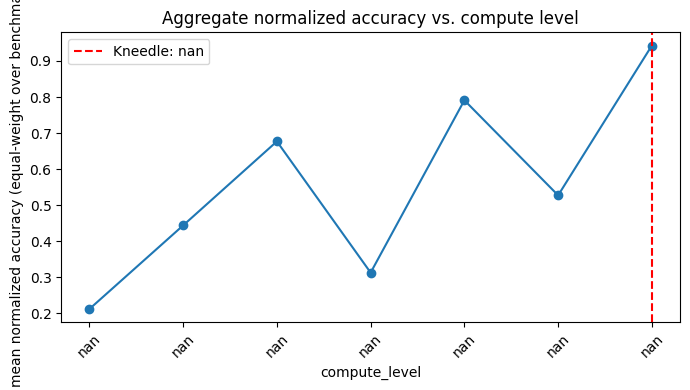

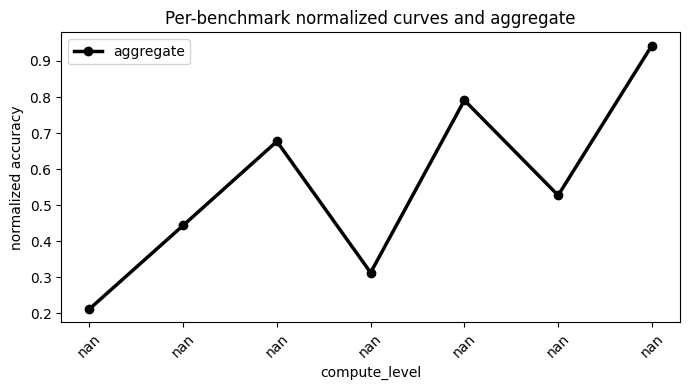

In [72]:
# ---- 3.4 Figures ---------------------------------------------------------------
levels = compute_level_agg["compute_level"].tolist()
level_pos = {lv: i for i, lv in enumerate(levels)}
x_pos = np.arange(len(levels))

# fig9: aggregate normalized curve + Kneedle marker
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_pos, compute_level_agg["mean_normalized_accuracy"], marker="o")
if aggregate_knee is not None:
    ax.axvline(level_pos[aggregate_knee], color="red", linestyle="--", label=f"Kneedle: {aggregate_knee}")
    ax.legend()
ax.set_xticks(x_pos); ax.set_xticklabels(levels, rotation=45)
ax.set_xlabel("compute_level"); ax.set_ylabel("mean normalized accuracy (equal-weight over benchmarks)")
ax.set_title("Aggregate normalized accuracy vs. compute level")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_compute_level_normalized_aggregate.png", dpi=150)
plt.show()

# fig10: per-benchmark normalized curves behind the aggregate
fig, ax = plt.subplots(figsize=(7, 4))
for bench, sub in bench_norm.dropna(subset=["normalized_accuracy"]).groupby(BENCHMARK_COL):
    sub = sub[sub["compute_level"].isin(level_pos)].copy()
    sub["pos"] = sub["compute_level"].map(level_pos)
    sub = sub.sort_values("pos")
    ax.plot(sub["pos"], sub["normalized_accuracy"], alpha=0.35, linewidth=1)
ax.plot(x_pos, compute_level_agg["mean_normalized_accuracy"], color="black", linewidth=2.5,
        marker="o", label="aggregate")
ax.set_xticks(x_pos); ax.set_xticklabels(levels, rotation=45)
ax.set_xlabel("compute_level"); ax.set_ylabel("normalized accuracy")
ax.set_title("Per-benchmark normalized curves and aggregate")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_benchmark_normalized_curves.png", dpi=150)
plt.show()

### 3.5 Compute-Level Outputs

Three files are written: per-benchmark normalized accuracy (with the min/max used, so it is auditable), the aggregate curve, and the aggregate Kneedle result (`None` is written as an empty value).

In [73]:
# ---- 3.5 Outputs ----------------------------------------------------------------
bench_norm.to_csv(BASE_DIR / "benchmark_normalized_accuracy.csv", index=False)
compute_level_agg.to_csv(BASE_DIR / "compute_level_normalized_aggregate.csv", index=False)
pd.DataFrame([dict(kneedle_optimal_compute_level=aggregate_knee)]).to_csv(
    BASE_DIR / "compute_level_kneedle_optimal.csv", index=False)
print("Wrote benchmark_normalized_accuracy.csv, compute_level_normalized_aggregate.csv, "
      "compute_level_kneedle_optimal.csv")

Wrote benchmark_normalized_accuracy.csv, compute_level_normalized_aggregate.csv, compute_level_kneedle_optimal.csv


# 4. OVER DIFFICULTY LEVEL ANALYSIS

This section mirrors Analyses 2 and 3, with **difficulty level** replacing benchmark as the grouping dimension. It also operates on the full raw dataframe and uses only `h1_raw_results.csv`.

**Difficulty is derived, not given.** For every question (identified by `benchmark` + `question_id`) we compute its **pass rate pooled over all samples and all compute levels**, then assign a difficulty band using fixed pass-rate edges in `CFG["difficulty"]`:

| Level | Pass-rate band |
|---|---|
| `D1_hard` | [0.00, 0.25) |
| `D2_medium_hard` | [0.25, 0.50) |
| `D3_medium_easy` | [0.50, 0.75) |
| `D4_easy` | [0.75, 1.00] |

Fixed bands (rather than quantiles) keep the meaning of a level identical across benchmarks. Pooling over compute levels means difficulty is not defined from any single level's outcomes.

**Caveat.** Because difficulty is computed from the same outcomes it is then used to stratify, the resulting curves carry a selection effect (e.g. the hardest band is by construction low-accuracy, and easy questions may be constant across levels). Read these results as descriptive shape, not as causal evidence.

## 4.1 Deriving Difficulty Levels

In [ ]:
# ---- 4.1 Per-question pass rate -> difficulty level ------------------------------
DIFF_KEY = [BENCHMARK_COL, "question_id"]
DIFF_LABELS = CFG["difficulty"]["labels"]      # ordered hardest -> easiest

question_difficulty = (
    raw_df.dropna(subset=["is_correct"])
    .groupby(DIFF_KEY)["is_correct"]
    .agg(question_pass_rate="mean", n_samples="size")
    .reset_index()
)
question_difficulty["difficulty_level"] = pd.cut(
    question_difficulty["question_pass_rate"],
    bins=CFG["difficulty"]["edges"], labels=DIFF_LABELS, right=False,
).astype(str)

# attach difficulty to every raw row (raw_df itself is left untouched)
diff_df = raw_df.merge(question_difficulty[DIFF_KEY + ["question_pass_rate", "difficulty_level"]],
                       on=DIFF_KEY, how="left")

difficulty_counts = (
    question_difficulty.groupby("difficulty_level")
    .agg(n_questions=("question_id", "size"), mean_pass_rate=("question_pass_rate", "mean"),
         n_samples=("n_samples", "sum"))
    .reindex(DIFF_LABELS).reset_index()
)
difficulty_counts.to_csv(BASE_DIR / "difficulty_level_counts.csv", index=False)
question_difficulty.to_csv(BASE_DIR / "question_difficulty.csv", index=False)
print(
    "Bands are FIXED absolute pass-rate cutoffs (0-25/25-50/50-75/75-100%), not quantiles, "
    "so group sizes are not expected to be equal -- an unequal split (e.g. D1/D4 larger than "
    "D2/D3) simply reflects a bimodal difficulty distribution in this data (many near-0% or "
    "near-100% pass-rate questions, fewer in the middle), not an error."
)
difficulty_counts

## 4.2 Accuracy by Compute Level for Each Difficulty Level

Analogue of Section 2.1. Accuracy is first computed per `(benchmark, difficulty, compute level)`, then averaged **equally across benchmarks** for each `(difficulty, compute level)` so that large benchmarks do not dominate a difficulty band. `n_benchmarks` and `n_samples` show how much data sits behind each point.

In [75]:
# ---- 4.2 Accuracy per (benchmark, difficulty, compute level), then equal-weight over benchmarks ----
bdl = (
    diff_df.dropna(subset=["difficulty_level", "is_correct"])
    .groupby([BENCHMARK_COL, "difficulty_level", "compute_level"])["is_correct"]
    .agg(accuracy="mean", n="size").reset_index()
)

difficulty_accuracy = (
    bdl.groupby(["difficulty_level", "compute_level"])
    .agg(accuracy=("accuracy", "mean"), n_benchmarks=(BENCHMARK_COL, "nunique"), n_samples=("n", "sum"))
    .reset_index()
)
difficulty_accuracy["compute_level"] = pd.Categorical(
    difficulty_accuracy["compute_level"], categories=_compute_order, ordered=True)
difficulty_accuracy["difficulty_level"] = pd.Categorical(
    difficulty_accuracy["difficulty_level"], categories=DIFF_LABELS, ordered=True)
difficulty_accuracy = difficulty_accuracy.sort_values(["difficulty_level", "compute_level"]).reset_index(drop=True)
difficulty_accuracy.head(10)

,difficulty_level,compute_level,accuracy,n_benchmarks,n_samples
0,D1_hard,0,0.075000,8,130
1,D1_hard,256,0.064583,8,129
2,D1_hard,512,0.147222,8,129
3,D1_hard,1024,0.036111,8,128
4,D1_hard,2048,0.127778,8,129
5,D1_hard,4096,0.102917,8,130
6,D1_hard,8192,0.161250,8,130
7,D2_medium_hard,0,0.209524,7,65
8,D2_medium_hard,256,0.323810,7,64
9,D2_medium_hard,512,0.330952,7,65


### 4.3 Difficulty Accuracy Curves and Kneedle-Based Optimal Compute Level

Analogue of Sections 2.2-2.3: one accuracy-vs-compute curve per difficulty level (**fig11**), and Kneedle (same function, same ordinal x-axis) applied to each. Levels with fewer than 3 compute levels or no detected knee get `None`.

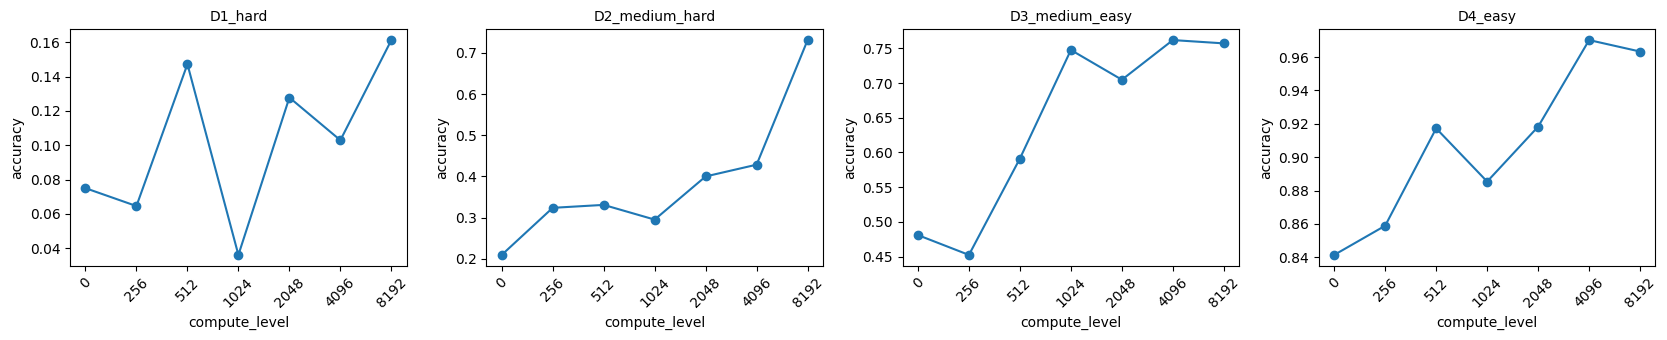

,difficulty_level,kneedle_optimal_compute_level
0,D1_hard,0
1,D2_medium_hard,256
2,D3_medium_easy,0
3,D4_easy,512


In [76]:
# ---- 4.3 Curves + Kneedle per difficulty level ---------------------------------------
present_diff = [d for d in DIFF_LABELS if d in set(difficulty_accuracy["difficulty_level"].astype(str))]

# fig11: raw (benchmark-equal-weight) accuracy curves, one panel per difficulty level
fig, axes = plt.subplots(1, max(len(present_diff), 1), figsize=(4.2 * max(len(present_diff), 1), 3.5), squeeze=False)
for ax, d in zip(axes[0], present_diff):
    sub = difficulty_accuracy[difficulty_accuracy["difficulty_level"].astype(str) == d]
    ax.plot(sub["compute_level"].astype(str), sub["accuracy"], marker="o")
    ax.set_title(d, fontsize=10)
    ax.set_xlabel("compute_level"); ax.set_ylabel("accuracy")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig11_difficulty_accuracy_curves.png", dpi=150)
plt.show()

diff_knee_rows = []
for d in present_diff:
    sub = difficulty_accuracy[difficulty_accuracy["difficulty_level"].astype(str) == d].dropna(subset=["accuracy"])
    knee = kneedle_optimal_level(sub["compute_level"].astype(str).tolist(), sub["accuracy"].tolist())
    diff_knee_rows.append(dict(difficulty_level=d, kneedle_optimal_compute_level=knee))
difficulty_kneedle = pd.DataFrame(diff_knee_rows)

difficulty_accuracy_out = difficulty_accuracy.copy()
difficulty_accuracy_out["compute_level"] = difficulty_accuracy_out["compute_level"].astype(str)
difficulty_accuracy_out["difficulty_level"] = difficulty_accuracy_out["difficulty_level"].astype(str)
difficulty_accuracy_out.to_csv(BASE_DIR / "difficulty_accuracy_by_compute_level.csv", index=False)
difficulty_kneedle.to_csv(BASE_DIR / "difficulty_kneedle_optimal_compute_level.csv", index=False)
difficulty_kneedle

## 4.4 Normalized Accuracy by Difficulty Level

Analogue of Section 3. To make the *shape* of the compute response comparable across difficulty levels (whose raw accuracy ranges differ by construction), each `(benchmark, difficulty)` curve is **min-max normalized across compute levels**, then the normalized curves are **averaged equally across benchmarks** for each `(difficulty, compute level)`:

```
normalized_accuracy = (accuracy - curve_min) / (curve_max - curve_min)
```

A `(benchmark, difficulty)` curve that is constant across compute levels (0/0) is **excluded** rather than given an invented value; this is common for the easiest band. Normalized values are meaningful only as shape, not as accuracy. Kneedle is then applied to each difficulty's aggregate normalized curve (**fig12**).

30 (benchmark, difficulty) curves | 0 constant curve(s) excluded from the normalized aggregate


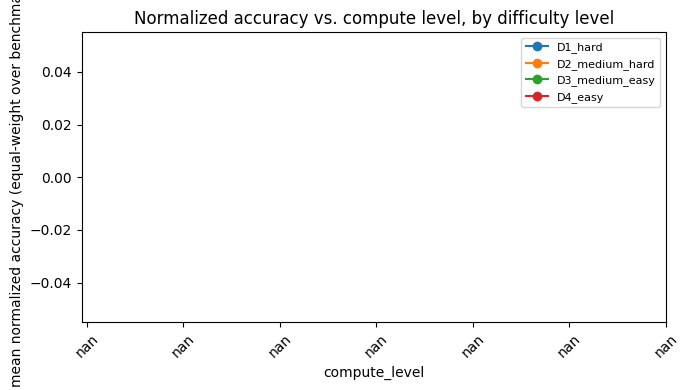

,difficulty_level,kneedle_optimal_compute_level
0,D1_hard,0
1,D2_medium_hard,256
2,D3_medium_easy,0
3,D4_easy,0


In [77]:
# ---- 4.4 Normalize within (benchmark, difficulty), average equally over benchmarks -------
curve_range = (
    bdl.groupby([BENCHMARK_COL, "difficulty_level"])["accuracy"]
    .agg(curve_min="min", curve_max="max").reset_index()
)
curve_range["acc_range"] = curve_range["curve_max"] - curve_range["curve_min"]
curve_range["is_constant"] = np.isclose(curve_range["acc_range"], 0.0)

diff_norm = bdl.merge(curve_range, on=[BENCHMARK_COL, "difficulty_level"], how="left")
diff_norm["normalized_accuracy"] = np.where(
    diff_norm["is_constant"], np.nan,
    (diff_norm["accuracy"] - diff_norm["curve_min"]) / diff_norm["acc_range"].replace(0, np.nan),
)
n_const = int(curve_range["is_constant"].sum())
print(f"{len(curve_range)} (benchmark, difficulty) curves | {n_const} constant curve(s) excluded from the normalized aggregate")

difficulty_norm_agg = (
    diff_norm.dropna(subset=["normalized_accuracy"])
    .groupby(["difficulty_level", "compute_level"])
    .agg(mean_normalized_accuracy=("normalized_accuracy", "mean"),
         sd_normalized_accuracy=("normalized_accuracy", "std"),
         n_benchmarks=(BENCHMARK_COL, "nunique"))
    .reset_index()
)
difficulty_norm_agg["compute_level"] = pd.Categorical(
    difficulty_norm_agg["compute_level"], categories=_compute_order, ordered=True)
difficulty_norm_agg["difficulty_level"] = pd.Categorical(
    difficulty_norm_agg["difficulty_level"], categories=DIFF_LABELS, ordered=True)
difficulty_norm_agg = difficulty_norm_agg.sort_values(["difficulty_level", "compute_level"]).reset_index(drop=True)
difficulty_norm_agg["compute_level"] = difficulty_norm_agg["compute_level"].astype(str)
difficulty_norm_agg["difficulty_level"] = difficulty_norm_agg["difficulty_level"].astype(str)

# Kneedle per difficulty on the aggregate normalized curve
norm_knee_rows = []
for d in DIFF_LABELS:
    sub = difficulty_norm_agg[difficulty_norm_agg["difficulty_level"] == d]
    if len(sub) == 0:
        continue
    knee = kneedle_optimal_level(sub["compute_level"].tolist(), sub["mean_normalized_accuracy"].tolist())
    norm_knee_rows.append(dict(difficulty_level=d, kneedle_optimal_compute_level=knee))
difficulty_norm_kneedle = pd.DataFrame(norm_knee_rows)

# fig12: aggregate normalized curve per difficulty level (Kneedle marked with a dashed line)
fig, ax = plt.subplots(figsize=(7, 4))
for d in DIFF_LABELS:
    sub = difficulty_norm_agg[difficulty_norm_agg["difficulty_level"] == d]
    if len(sub) == 0:
        continue
    xs = [level_pos[c] for c in sub["compute_level"] if c in level_pos]
    line, = ax.plot(xs, sub.loc[sub["compute_level"].isin(level_pos), "mean_normalized_accuracy"],
                    marker="o", label=d)
    knee_row = difficulty_norm_kneedle[difficulty_norm_kneedle["difficulty_level"] == d]
    if len(knee_row) and knee_row["kneedle_optimal_compute_level"].iloc[0] in level_pos:
        ax.axvline(level_pos[knee_row["kneedle_optimal_compute_level"].iloc[0]],
                   color=line.get_color(), linestyle="--", alpha=0.5)
ax.set_xticks(x_pos); ax.set_xticklabels(levels, rotation=45)
ax.set_xlabel("compute_level"); ax.set_ylabel("mean normalized accuracy (equal-weight over benchmarks)")
ax.set_title("Normalized accuracy vs. compute level, by difficulty level")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig12_difficulty_normalized_curves.png", dpi=150)
plt.show()

diff_norm.to_csv(BASE_DIR / "difficulty_normalized_accuracy.csv", index=False)
difficulty_norm_agg.to_csv(BASE_DIR / "difficulty_normalized_aggregate.csv", index=False)
difficulty_norm_kneedle.to_csv(BASE_DIR / "difficulty_kneedle_normalized_optimal.csv", index=False)
difficulty_norm_kneedle

# 5. Final Summary

The summary below is generated from the computed objects (not hand-typed), so it always matches the current data. All Study 1 / 2 / 3 findings are **descriptive associations**; nothing here supports a causal claim (for example, "longer paths contain more repetition" is an association within groups, not evidence that length *causes* repetition).

In [ ]:
# ---- Final textual summary --------------------------------------------------------
line = "=" * 78

# ---------------- Study 1 ----------------
n_s1_groups = path_metrics[GK].drop_duplicates().shape[0]
n_s1_spread = int((s1_group_summary["token_ratio"] >= MIN_LEN_RATIO).sum())
print(line); print("STUDY 1: all-correct, high-dispersion groups"); print(line)
print(f"Eligible groups: {n_s1_groups} ({len(path_metrics)} paths) | "
      f"groups with substantial length spread (max/min >= {MIN_LEN_RATIO}): {n_s1_spread}")

print("\nWithin-group associations with thinking_tokens (question-level bootstrap, "
      f"{CFG['n_boot']} resamples over questions; associations only):")
display(within_group_stats[[
    "metric", "spearman_mean", "spearman_ci_lo", "spearman_ci_hi",
    "mean_diff", "ci_lo", "ci_hi", "bootstrap_p", "standardized_diff", "p_holm",
]].round(3))

print("\nExtra-token attribution (share of the longest-minus-shortest extra tokens, by bucket):")
display(extra_token_bootstrap.round(3))

print(f"\nScore vs. length: Spearman(efficiency_score, thinking_tokens) = {rho_len:.3f}, "
      f"R^2 of linear fit = {ols_len.rsquared:.3f}")
print("Sanity-check status counts:", sanity_checks["status"].value_counts().to_dict())

# ---------------- Study 2 / 3 ----------------
n_mixed_groups = mixed_path_metrics[GK].drop_duplicates().shape[0]
n_aw_groups = allwrong_path_metrics[GK].drop_duplicates().shape[0]
print("\n" + line); print("STUDY 2 / STUDY 3: mixed-outcome and all-wrong groups"); print(line)
print(f"Study 2: {n_mixed_groups} mixed groups, {len(mixed_path_metrics)} paths")
print(f"Study 3: {n_aw_groups} all-wrong groups, {len(allwrong_path_metrics)} paths")

print("\nStudy 2 trajectory composition (share of paths):")
display(mixed_path_metrics["trajectory_shape"].value_counts(normalize=True).round(3))
print("Study 3 trajectory composition (share of paths):")
display(allwrong_composition.round(3))
print(f"Study 3 never_found rate: {allwrong_composition.get('never_found', 0.0):.1%} | "
      f"found_then_lost rate: {allwrong_composition.get('found_then_lost', 0.0):.1%}")

print("\nStudy 2 timing contrast, mean(metric | incorrect) - mean(metric | correct):")
display(divergence_timing_contrast.round(3))

div_all = pd.concat([mixed_path_metrics["divergence_frac"], allwrong_path_metrics["divergence_frac"]]).dropna()
if len(div_all):
    print(f"\nfound_then_lost divergence position: n={len(div_all)}, "
          f"median={div_all.median():.2f}, IQR=({div_all.quantile(.25):.2f}, {div_all.quantile(.75):.2f}) "
          f"of trace length")
print(f"ends_correct vs is_correct agreement (Study 2): {ends_correct_agreement:.1%}")
print("Trajectory classifier synthetic checks:",
      divergence_classifier_checks["status"].value_counts().to_dict())
print("ref_source distribution (Studies 2+3):", ref_source_dist.to_dict())

# ---------------- Benchmarks ----------------
print("\n" + line); print("BENCHMARK ANALYSIS: accuracy curves and Kneedle-selected compute levels"); print(line)
display(benchmark_accuracy_out.pivot(index=BENCHMARK_COL, columns="compute_level", values="accuracy")
        .reindex(columns=_compute_order_str).round(3))
display(benchmark_kneedle)

# ---------------- Compute level ----------------
print("\n" + line); print("COMPUTE-LEVEL ANALYSIS: normalized aggregate curve"); print(line)
display(compute_level_agg.round(3))
print(f"Kneedle-selected compute level (aggregate): {aggregate_knee}")
if constant_benchmarks:
    print(f"Excluded from normalized aggregate (constant accuracy): {constant_benchmarks}")

# ---------------- Difficulty level ----------------
print("\n" + line); print("DIFFICULTY-LEVEL ANALYSIS: accuracy and normalized curves by difficulty"); print(line)
display(difficulty_counts.round(3))
display(difficulty_accuracy_out.pivot(index="difficulty_level", columns="compute_level", values="accuracy")
        .reindex(index=DIFF_LABELS, columns=_compute_order_str).round(3))
print("Kneedle on raw (benchmark-equal-weight) accuracy curves:")
display(difficulty_kneedle)
print("Kneedle on normalized aggregate curves:")
display(difficulty_norm_kneedle)
print(f"Constant (benchmark, difficulty) curves excluded from normalization: {n_const}")

print("\nAll findings above are descriptive associations, not causal claims.")